In [10]:
import pandas as pd


url = "https://raw.githubusercontent.com/vbabashov/house-prices/refs/heads/main/data/raw/train.csv"
df = pd.read_csv(url)

df.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:

print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("\nData Types Count:\n", df.dtypes.value_counts())
print("\nTop Missing Value Columns:\n", df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Dataset Shape: (1460, 81)
Duplicate Rows: 0

Data Types Count:
 object     43
int64      35
float64     3
Name: count, dtype: int64

Top Missing Value Columns:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


there exist alot of nulls in our data and 0 duplicates

In [12]:


# Target Variable
target = ["SalePrice"]

# Numerical Features
num_continuous = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
]

num_discrete = [
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
    "MoSold",
    "YrSold",
]

# Combined Numerical Features list
numerical_features = num_continuous + num_discrete

# Nominal Categorical Features
nominal_features = [
    "Neighborhood",
    "MSZoning",
    "BldgType",
    "HouseStyle",
    "Foundation",
    "Exterior1st",
    "Exterior2nd",
    "RoofStyle",
    "SaleType",
    "SaleCondition",
    "Alley",
]

# Ordinal Categorical Features
ordinal_features = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "LotShape",
    "Utilities",
]

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

`target variable`

[Text(0.5, 1.0, 'Original SalePrice (Skew: 1.88)')]

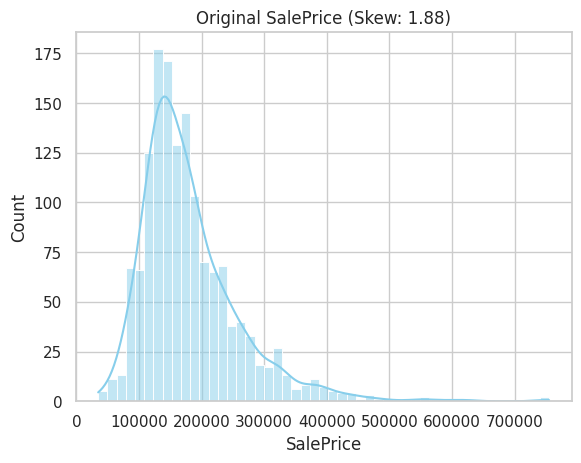

In [14]:
df["SalePrice"].skew()
sns.histplot(df["SalePrice"], kde=True, color='skyblue').set(title=f"Original SalePrice (Skew: {df['SalePrice'].skew():.2f})")

we have severe right skewness in our target variable        will need handling later with yeojhonson or even log works

`continous features`

In [15]:
df[num_continuous].describe()

,GrLivArea,LotArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageArea,LotFrontage,MasVnrArea
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1452.000000
mean,1515.463699,10516.828082,1057.429452,1162.626712,346.992466,472.980137,70.049958,103.685262
std,525.480383,9981.264932,438.705324,386.587738,436.528436,213.804841,24.284752,181.066207
min,334.000000,1300.000000,0.000000,334.000000,0.000000,0.000000,21.000000,0.000000
25%,1129.500000,7553.500000,795.750000,882.000000,0.000000,334.500000,59.000000,0.000000
50%,1464.000000,9478.500000,991.500000,1087.000000,0.000000,480.000000,69.000000,0.000000
75%,1776.750000,11601.500000,1298.250000,1391.250000,728.000000,576.000000,80.000000,166.000000
max,5642.000000,215245.000000,6110.000000,4692.000000,2065.000000,1418.000000,313.000000,1600.000000


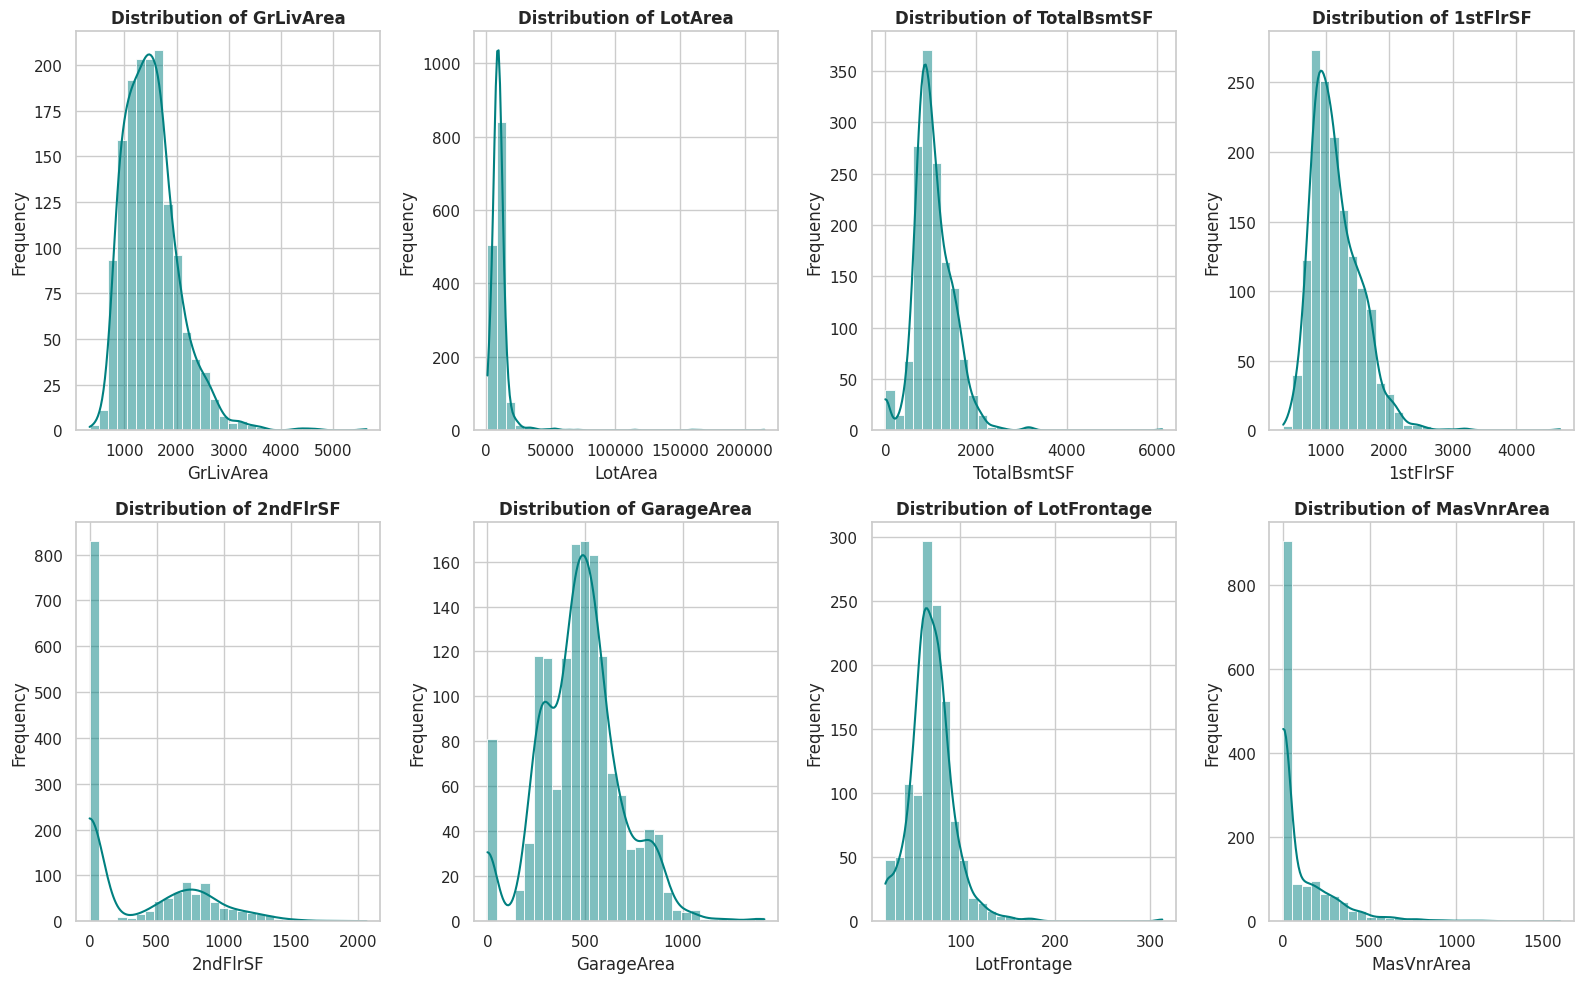

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_continuous):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal", bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

LotArea has a mean of 10,516 a median of 9,478 and a max of 215,245 high right skewness

Masvnr area has a median and 75th% of 166 with a max of 1600 highly skewed data as well, shows massive 0 infilation which makes it a good candidate for "hasmasvnr"

second floor also has a median of 0 and max of 2065 

for the GRlivArea the 75th% of homes are under 1.8k but max is at 5.6k, the author of the dataset DeanDeCock highlights that the data contains homes with GrLivArea > 4,000 sq ft that sold for unusually low prices

2nd floor is a primary candidate of "has2ndfloor" since the data spikes at 0 mostly

garage area exhibits a clusters or multipeak distributions at 1 car, 2car and 3 car sizes

`continous features vs target salesprice`

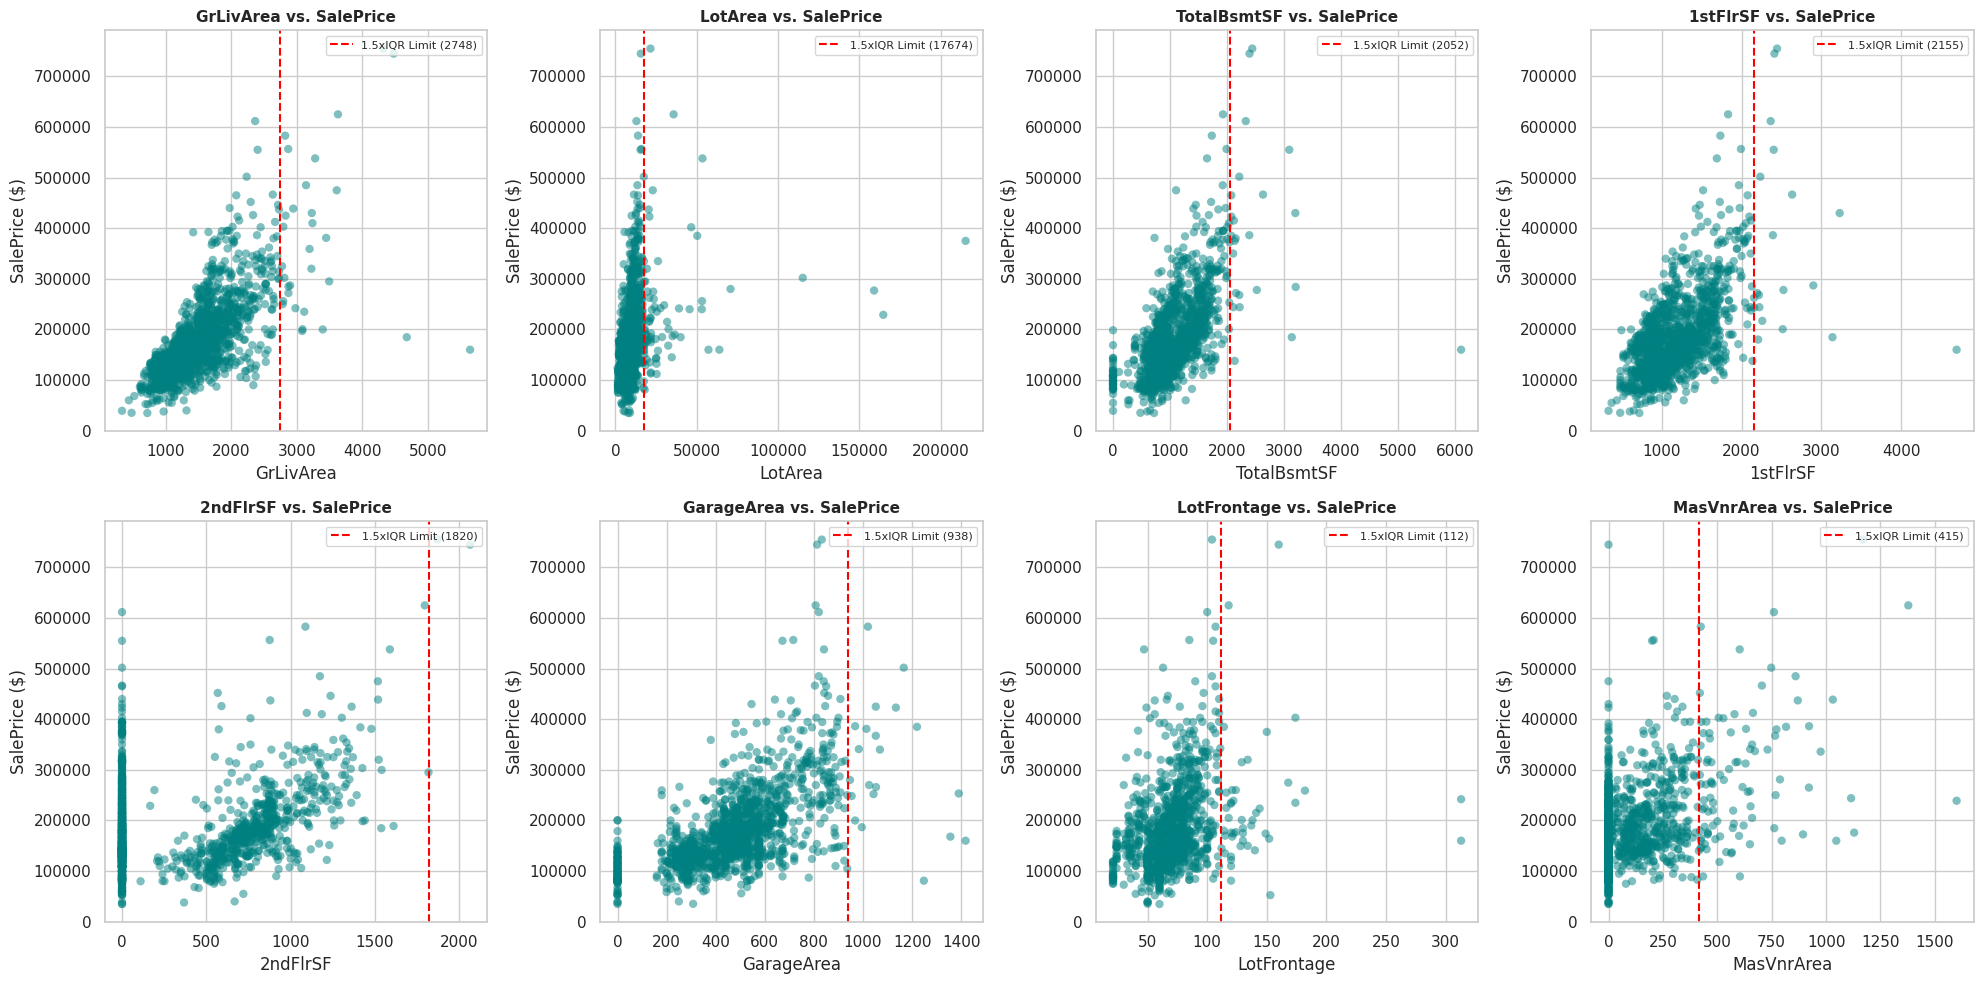

In [17]:


# Continuous features from your grid
num_continuous = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_continuous):
    if col in df.columns and "SalePrice" in df.columns:
        # Calculate IQR upper bound for the current feature
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr

        # Plot scatter
        sns.scatterplot(
            data=df,
            x=col,
            y="SalePrice",
            ax=axes[i],
            alpha=0.5,
            color="teal",
            edgecolor="none",
        )

        # Draw red dashed line at Upper Bound threshold
        axes[i].axvline(
            upper_bound,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"1.5xIQR Limit ({upper_bound:.0f})",
        )

        axes[i].set_title(f"{col} vs. SalePrice", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("SalePrice ($)")
        axes[i].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

here again we can see the GrLivArea above 4k we have some dots that feel off which DeanDeCock highlighted

further more strengthens the key takeaways that we included after seeing the skewness

`outliers for continous features`

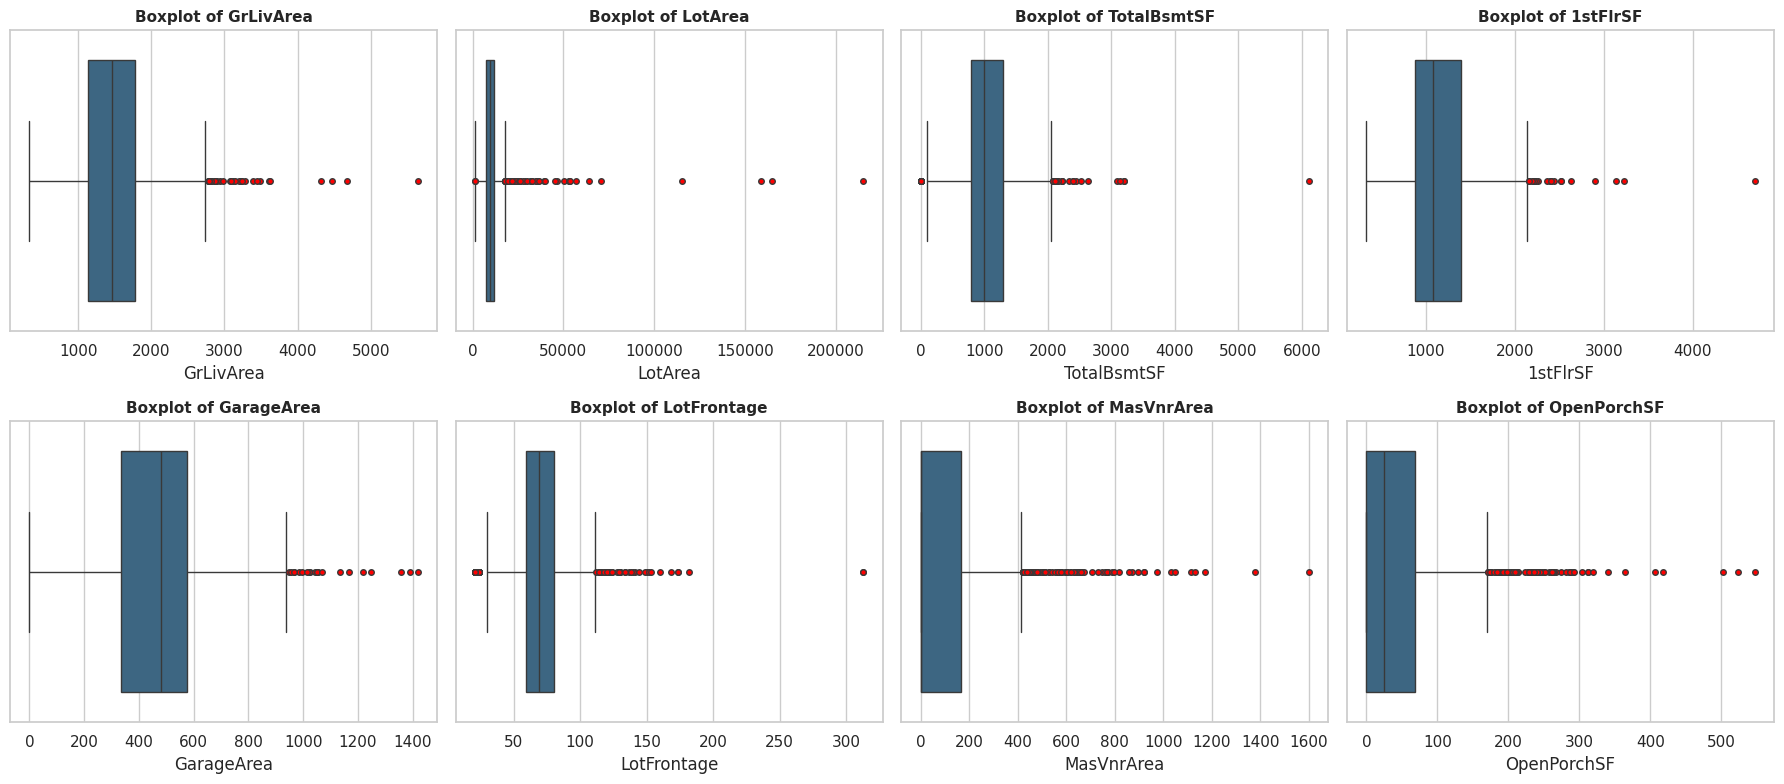

In [18]:


# Continuous features to check for extreme outliers
continuous_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
    "OpenPorchSF",
]

# Filter features that exist in df
valid_features = [col for col in continuous_features if col in df.columns]

# Create Box Plots Grid
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(valid_features):
    sns.boxplot(
        data=df, x=col, ax=axes[i], color="#31688e", flierprops={"markerfacecolor": "red", "markersize": 4}
    )
    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)

# Hide unused subplots if features < 8
for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
# Compute IQR Outliers
outlier_summary = []

for col in valid_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ].shape[0]
    pct_outliers = (outliers_count / len(df)) * 100

    outlier_summary.append(
        {
            "Feature": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Upper Bound": round(upper_bound, 2),
            "Outliers Count": outliers_count,
            "Outliers %": f"{pct_outliers:.2f}%",
        }
    )

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Q1,Q3,IQR,Upper Bound,Outliers Count,Outliers %
0,GrLivArea,1129.50,1776.75,647.25,2747.62,31,2.12%
1,LotArea,7553.50,11601.50,4048.00,17673.50,69,4.73%
2,TotalBsmtSF,795.75,1298.25,502.50,2052.00,61,4.18%
3,1stFlrSF,882.00,1391.25,509.25,2155.12,20,1.37%
4,GarageArea,334.50,576.00,241.50,938.25,21,1.44%
5,LotFrontage,59.00,80.00,21.00,111.50,88,6.03%
6,MasVnrArea,0.00,166.00,166.00,415.00,96,6.58%
7,OpenPorchSF,0.00,68.00,68.00,170.00,77,5.27%


as officially recommended by DeanDeCock dropping rows where GrLivArea > 4000 removes non typical/partial sales 

TotalBsmtSF Features an extreme outlier sitting at 6000+sqft (which matches the 5000+sqft GrLivArea outlier) and dropping the extreme GrLivArea usually drops the TotalBsmtSF outlier with it

LotArea and LotFrontage outliers are legitement and needs handling using yeo jhonson or log

the MasVnr and OpenPorch are legit data but the Q1 is squashed to 0 due to alot of houses not having any porches or masonry veneers

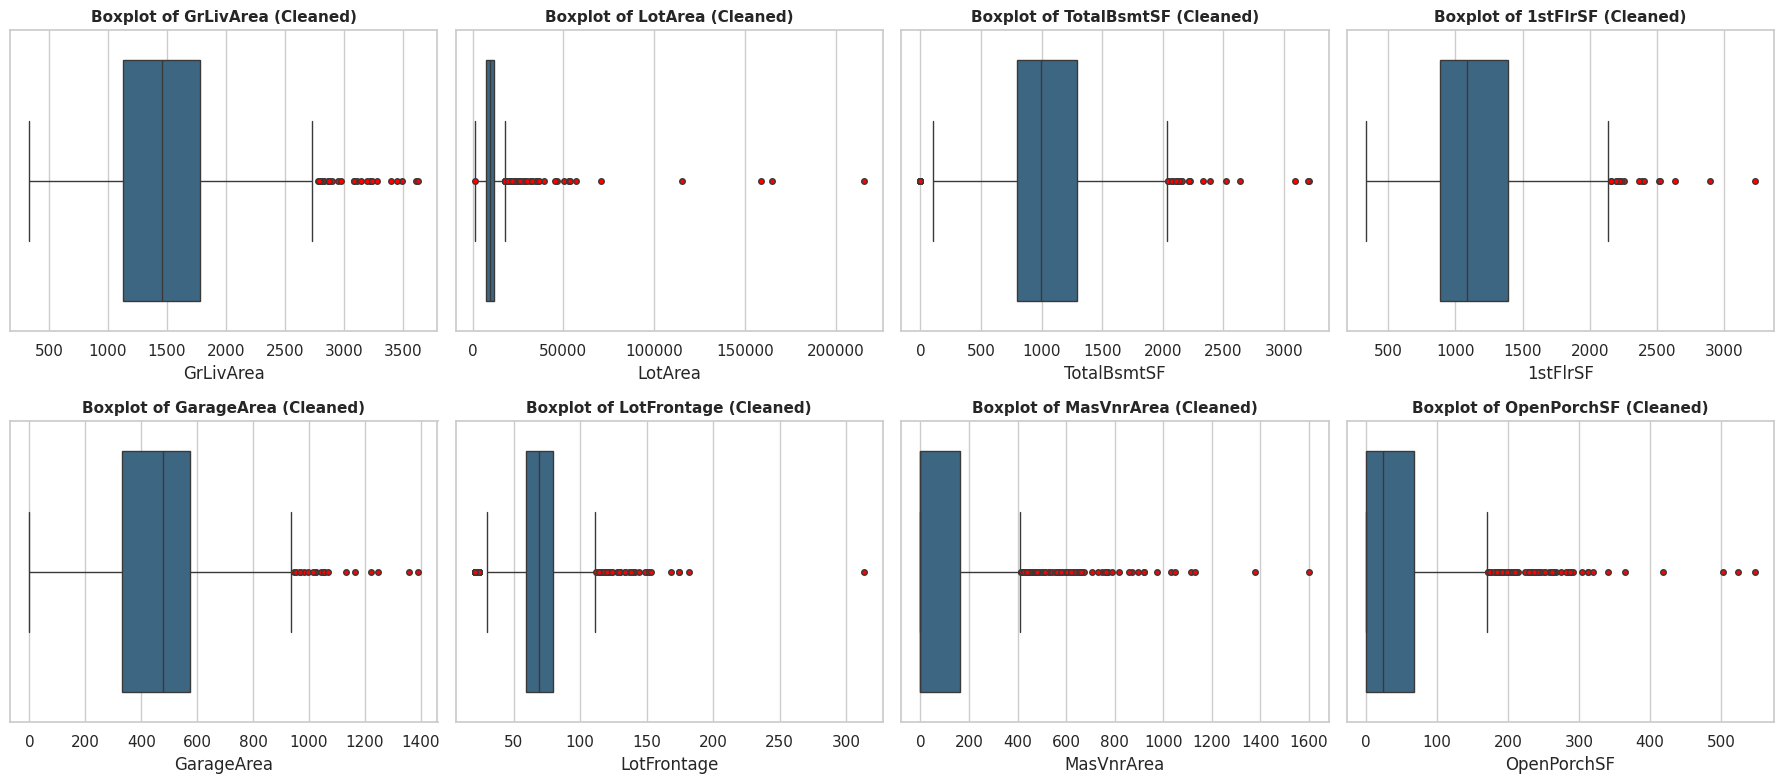

In [20]:


# 1. Filter out extreme leverage outliers (GrLivArea >= 4000)
df_cleaned = df[df["GrLivArea"] < 4000].copy()

# 2. Continuous features list
valid_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
    "OpenPorchSF",
]

# 3. Plot updated Box Plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(valid_features):
    if col in df_cleaned.columns:
        sns.boxplot(
            data=df_cleaned,
            x=col,
            ax=axes[i],
            color="#31688e",
            flierprops={"markerfacecolor": "red", "markersize": 4},
        )
        axes[i].set_title(
            f"Boxplot of {col} (Cleaned)", fontsize=11, fontweight="bold"
        )
        axes[i].set_xlabel(col)

# Hide any extra empty subplots
for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


after dropping the extreme GrLivArea 

GrLivArea and TotalBsmSF leverage removed the extreme outliers have been removed

lot area and lotfrontage have natural skewness

the rest of the data roughly stayed the same


`discrete features`

In [21]:
df[num_discrete].describe()

,YearBuilt,YearRemodAdd,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,MoSold,YrSold
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1971.267808,1984.865753,1.565068,0.382877,2.866438,6.517808,0.613014,1.767123,6.321918,2007.815753
std,30.202904,20.645407,0.550916,0.502885,0.815778,1.625393,0.644666,0.747315,2.703626,1.328095
min,1872.000000,1950.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,2006.000000
25%,1954.000000,1967.000000,1.000000,0.000000,2.000000,5.000000,0.000000,1.000000,5.000000,2007.000000
50%,1973.000000,1994.000000,2.000000,0.000000,3.000000,6.000000,1.000000,2.000000,6.000000,2008.000000
75%,2000.000000,2004.000000,2.000000,1.000000,3.000000,7.000000,1.000000,2.000000,8.000000,2009.000000
max,2010.000000,2010.000000,3.000000,2.000000,8.000000,14.000000,3.000000,4.000000,12.000000,2010.000000


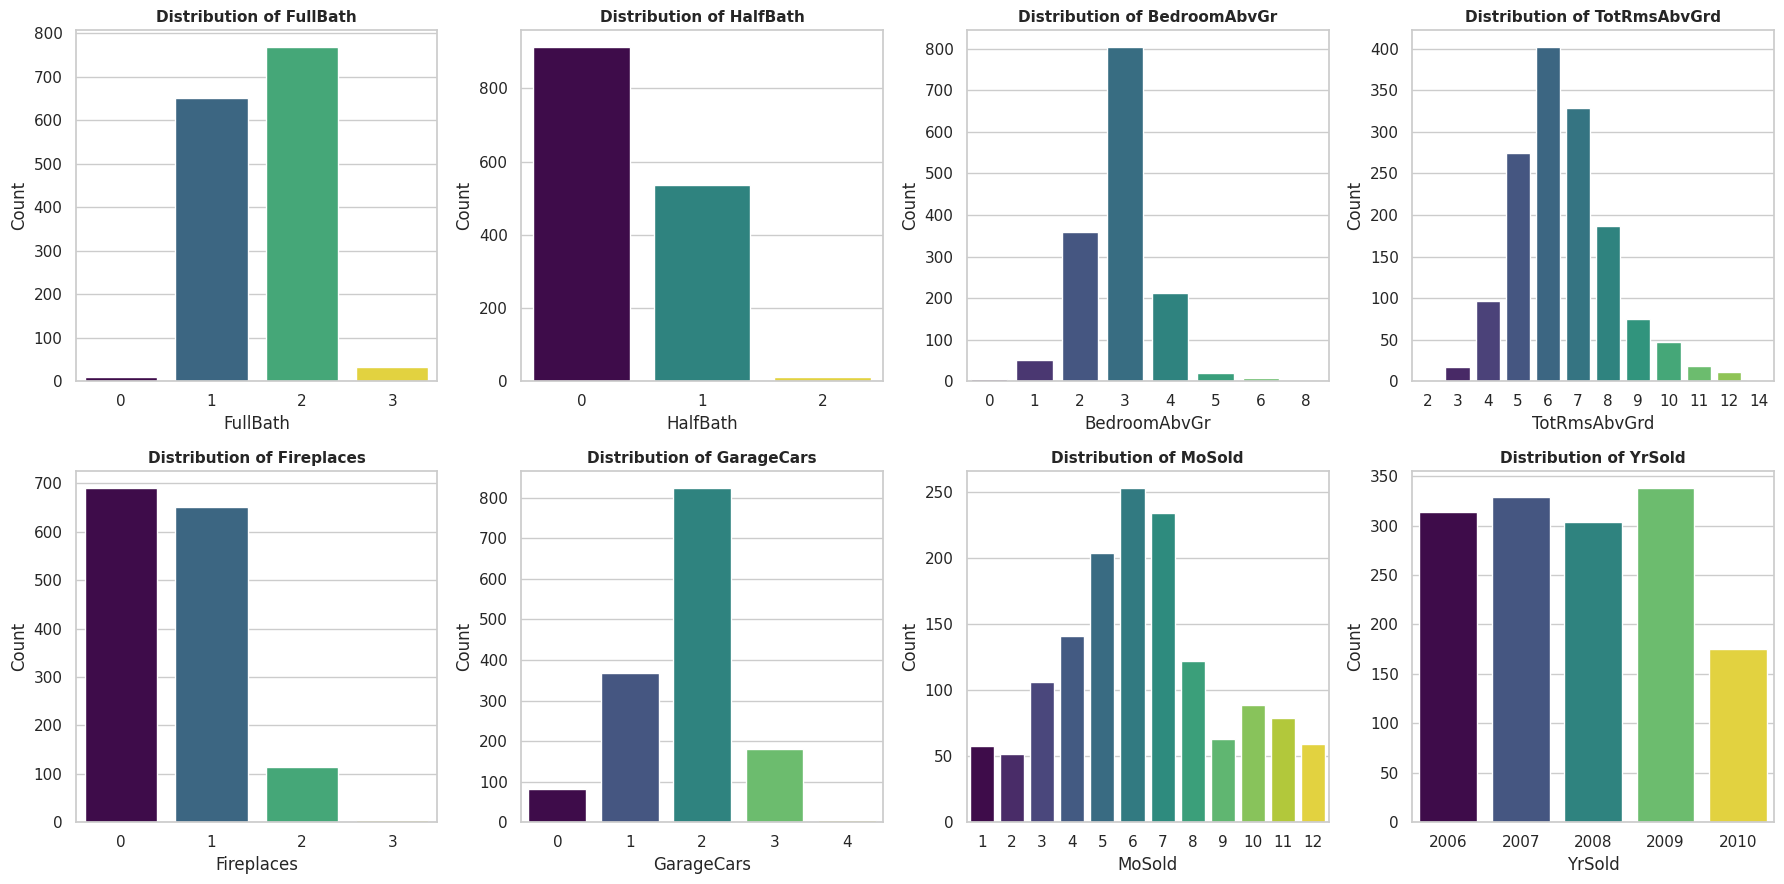

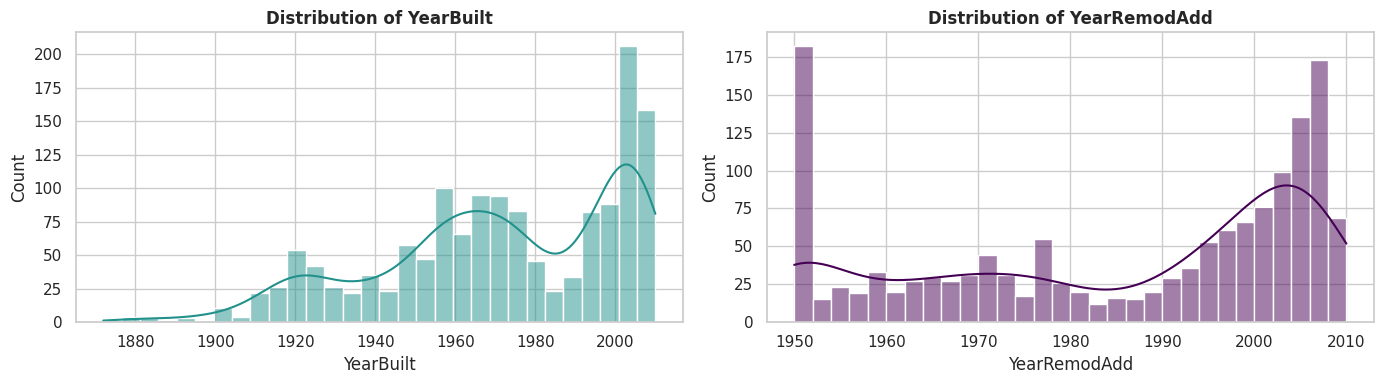

In [22]:


# Clean list without year features in countplot
discrete_features = [
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
    "MoSold",
    "YrSold",
]

# Grid for discrete count features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(discrete_features):
    # Added hue=col and legend=False to fix the Seaborn v0.14+ deprecation warning
    sns.countplot(
        data=df, x=col, hue=col, ax=axes[i], palette="viridis", legend=False
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Separate Histograms for Year Features (prevents squished x-axis labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["YearBuilt"], kde=True, ax=axes[0], color="#21918c", bins=30)
axes[0].set_title("Distribution of YearBuilt", fontweight="bold")

sns.histplot(
    df["YearRemodAdd"], kde=True, ax=axes[1], color="#440154", bins=30
)
axes[1].set_title("Distribution of YearRemodAdd", fontweight="bold")

plt.tight_layout()
plt.show()

no nulls on numerical discrete features, the data set lies between 2006 and 2010

raw year numbers arent ideal for linear ML models cols like houseage and remodage might be added

full bath and half bath can be combined into 1 feature

cyclic encoding might be considered for the yr/mo sold features

standard 3 bedroom dominates 

totrmsabv average follows a noral distribution centered at 6

as for garage 2 car slots is the standard for most homes

fire places is a really good candidate of being replaced by a has fireplace as its mostly 0 or 1 with little to nothing above


as for the year built, shows a minor surge at 1920 and post WWII housing boom around 1950-1970 and a massive expansion from 2000-2007 before the 2008 financial crisis, will probably make a new col HouseAge = yrsold-yrblt to avoid confusion in linear models 

as for the yearrmodadd, 1950 has a spike cuz no remods where set to 1950 in this dataset starting from 1990 to 2008 an upward trend in remodelling can be noticed, will probably make RemodAge = yrsold - yearremodadd to avoid cofusion in linear models

MoSold  show market seasonality in months 5 6 7 real estate drop sharply at november and till feb next year (consider cyclic encoding)

annual sales are evenly distributed 2006-2009 and drops at 2010 simply because the data collection endded at july

`ordinal features`

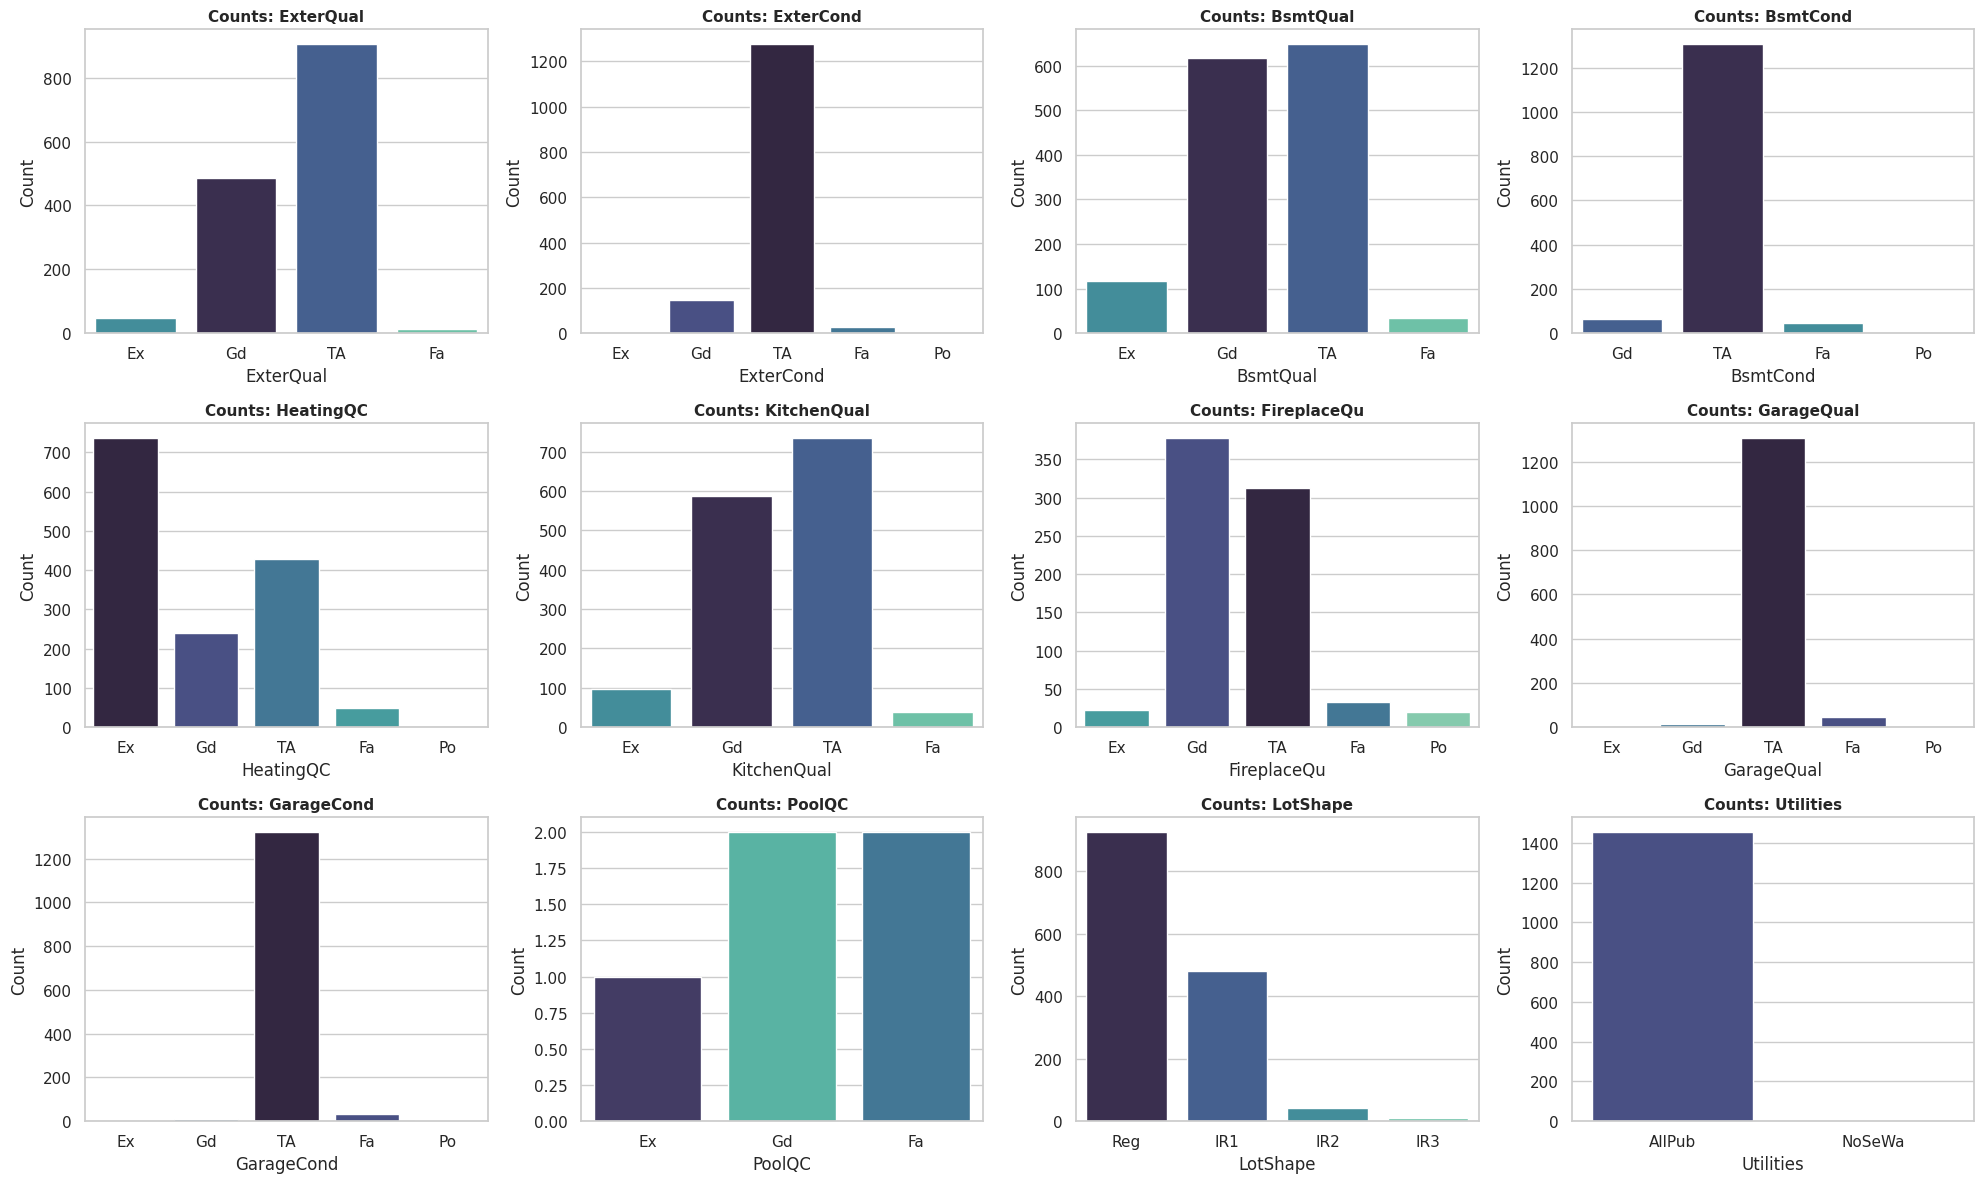

In [23]:


# Standard quality rating hierarchy
rating_order = ["Ex", "Gd", "TA", "Fa", "Po"]

# Create a 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_features):
    if col in df_cleaned.columns:
        # Determine order present in data
        unique_vals = df_cleaned[col].dropna().unique()
        col_order = [o for o in rating_order if o in unique_vals] + [
            o for o in unique_vals if o not in rating_order
        ]

        sns.countplot(
            data=df_cleaned,
            x=col,
            order=col_order,
            ax=axes[i],
            palette="mako",
            hue=col,
            legend=False,
        )
        axes[i].set_title(f"Counts: {col}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

# Hide extra subplots
for j in range(len(ordinal_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

severe class imabalnce, utitlies is only all pub, garageQual,garageCond,BsmtCond and extrCond are dominated by TA almost 90%+ 

exterqual , bsmt qual , heatingqual, kitchen qual, probably the most useful predictors for our model

poolqc has only 7 counts 



fire place has total count of around 750

`nominal features`

my goal is to indetify high caridnality, class distribution and variance aganist salesprice

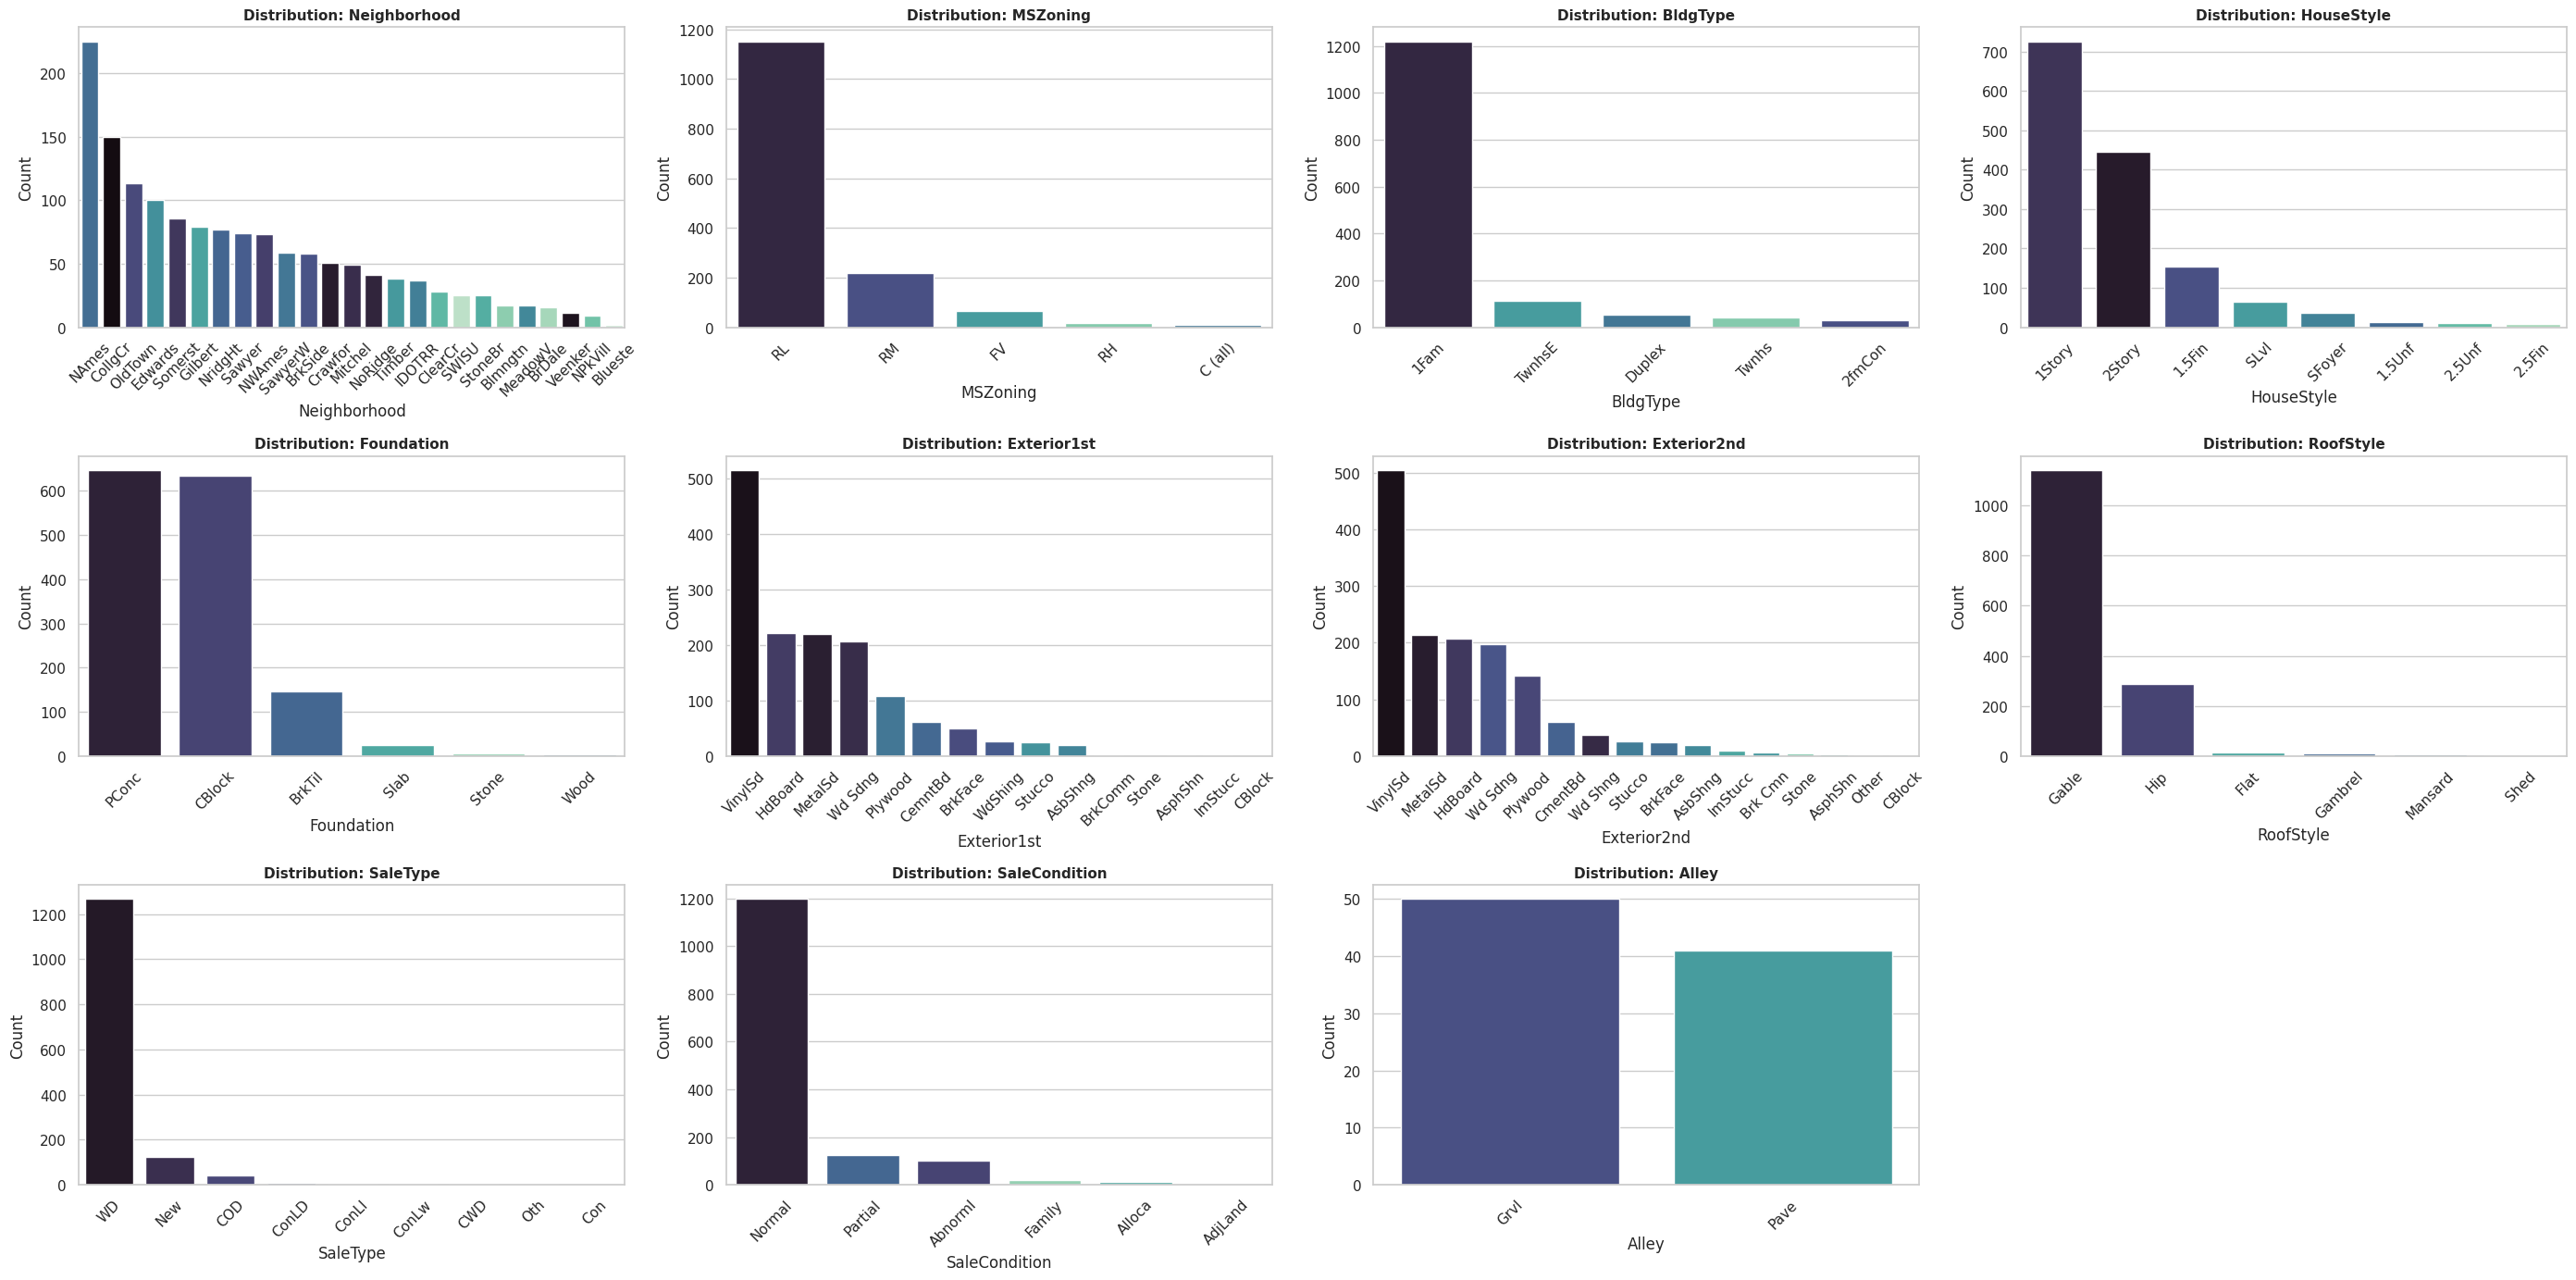

In [24]:

nominal_features = [
    "Neighborhood",
    "MSZoning",
    "BldgType",
    "HouseStyle",
    "Foundation",
    "Exterior1st",
    "Exterior2nd",
    "RoofStyle",
    "SaleType",
    "SaleCondition",
    "Alley",
]

# Grid setup (3x4 for 11 features)
fig, axes = plt.subplots(3, 4, figsize=(28, 14))
axes = axes.flatten()

for i, col in enumerate(nominal_features):
    if col in df.columns:
        # Sort categories by frequency
        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            ax=axes[i],
            palette="mako",
            hue=col,
            legend=False,
        )
        axes[i].set_title(f"Distribution: {col}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

# Remove the empty 12th subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

for sale type, sale condition, mszoning, bldgtype, rooftype we have severe class imbalance, one hot encoding will make cols with little to no variance

high cardinality features: neighborhood, exterior1st, exterior2nd, will probably target encode these mapping neighborhoods to their median saleprice

alley has so many nulls

`correlation analysis`

i dont think its the easiest to read a correlation matrix with so many features


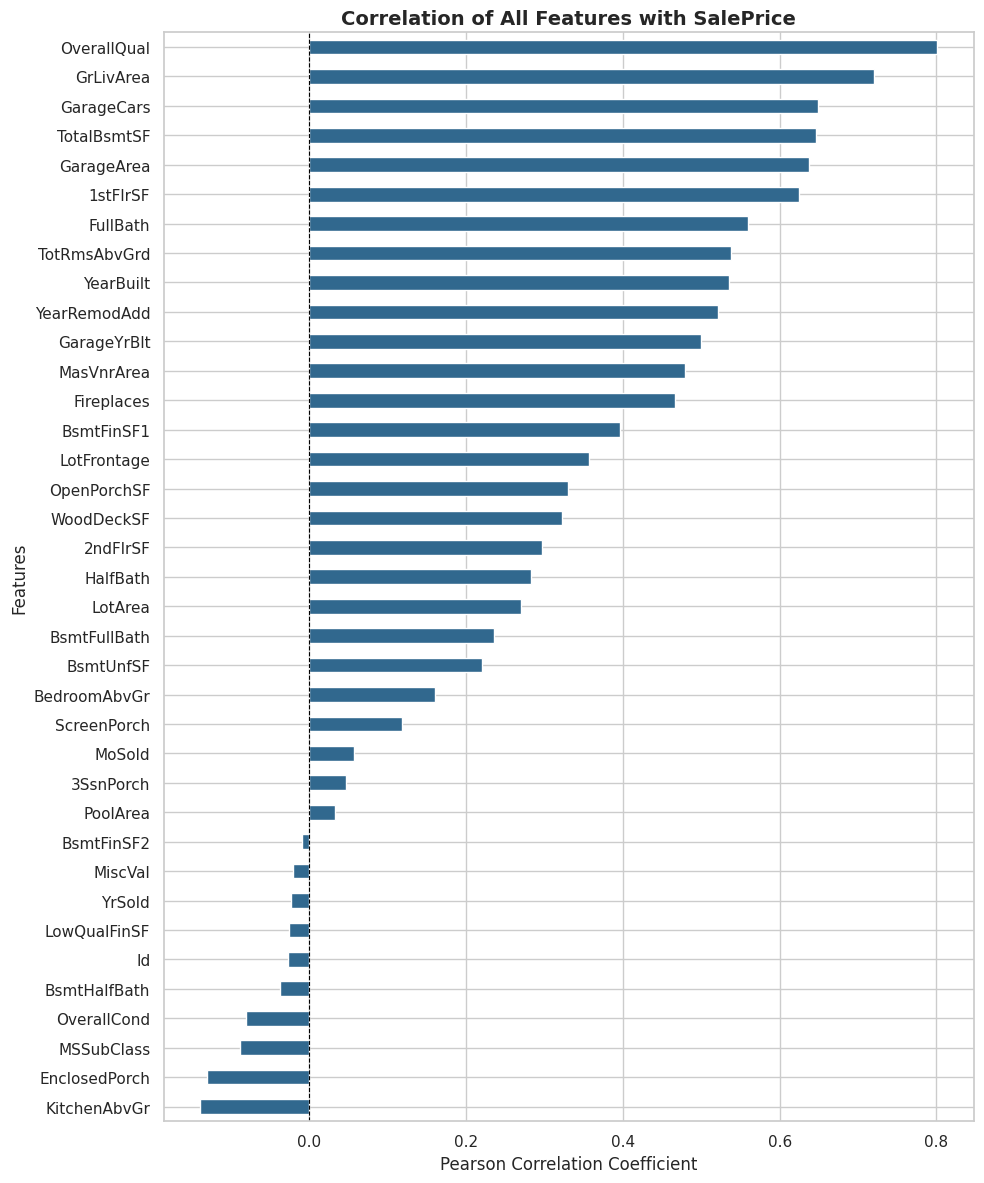

In [25]:
# Calculate correlation of all numeric features with SalePrice
saleprice_corr = (
    df_cleaned.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=True)
)

# Plot horizontal bar chart
plt.figure(figsize=(10, 12))
saleprice_corr.plot(kind="barh", color="#31688e")

plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlation of All Features with SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

overallqual and grlivarea are the most dominant in the dataset, they are the strongest drivers for salesprice

garagecars,garagearea,totalbsmtsf,1stflrsf all sti strongly correlated with salesprice

yrsold and monthsold have low correlation with salesprice because its cyclic and not a linear realation

pool area and porch has very low as well because most of these cols are straight zeros

kirchenabvgr and enclosed proch are highly negative because usually more than 1 kitchen signals multi-family/split properties which tend to sell for less per unit and older homes tend to have enclosed porches instead of modern open decks 

`house analysis`

In [26]:
df["SalePrice"].describe().apply(lambda x: round(x, 2))

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

mean is 180k while median is 163k which confirms the right skewness

In [27]:
min_house = df.loc[df['SalePrice'].idxmin()]
max_house = df.loc[df['SalePrice'].idxmax()]
print(f"Lowest Price House  -> ID: {min_house['Id']} | Price: ${min_house['SalePrice']:,}")
print(f"Highest Price House -> ID: {max_house['Id']} | Price: ${max_house['SalePrice']:,}")

Lowest Price House  -> ID: 496 | Price: $34,900
Highest Price House -> ID: 692 | Price: $755,000


In [28]:
top_5_pct = df[df['SalePrice'] >= df['SalePrice'].quantile(0.95)]
top_5_pct[['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']].describe().T[['mean', '50%', 'min', 'max']]

,mean,50%,min,max
GrLivArea,2421.013699,2364.0,1419.0,4476.0
OverallQual,8.657534,9.0,7.0,10.0
TotalBsmtSF,1747.616438,1746.0,728.0,3200.0
GarageCars,2.849315,3.0,2.0,3.0
YearBuilt,1998.219178,2005.0,1892.0,2010.0


the rating falls between 7-9 proving high quality is a very important feature (very intuitive as well)

massive sizes generally, the garages for 3 cars on average and mostly built recently with median of 2005

`neighborhood analysis`

In [29]:
# 1. Group and calculate describe statistics
neigh_stats = df.groupby("Neighborhood")["SalePrice"].describe()

# 2. Sort the entire dataframe by 'mean' in descending order
neigh_stats_sorted = neigh_stats.sort_values(by="mean", ascending=False)

# Top 3 most expensive neighborhoods
print("=== Top 3 Most Expensive Neighborhoods ===")
print(neigh_stats_sorted.head(3).round(2))

print("\n" + "="*60 + "\n")

# Bottom 3 least expensive neighborhoods
print("=== Bottom 3 Least Expensive Neighborhoods ===")
print(neigh_stats_sorted.tail(3).round(2))

print("\n" + "="*60 + "\n")

# Most frequent neighborhood
most_frequent = neigh_stats.sort_values(by="count", ascending=False).head(1)
print(f"Most Frequent Neighborhood: {most_frequent.index[0]} ({int(most_frequent['count'].values[0])} houses)")

=== Top 3 Most Expensive Neighborhoods ===
              count       mean        std       min       25%       50%  \
Neighborhood                                                              
NoRidge        41.0  335295.32  121412.66  190000.0  265000.0  301500.0   
NridgHt        77.0  316270.62   96392.54  154000.0  253293.0  315000.0   
StoneBr        25.0  310499.00  112969.68  170000.0  213500.0  278000.0   

                   75%       max  
Neighborhood                      
NoRidge       341000.0  755000.0  
NridgHt       374000.0  611657.0  
StoneBr       377426.0  556581.0  


=== Bottom 3 Least Expensive Neighborhoods ===
              count       mean       std      min      25%       50%  \
Neighborhood                                                           
BrDale         16.0  104493.75  14330.18  83000.0  91000.0  106000.0   
IDOTRR         37.0  100123.78  33376.71  34900.0  81000.0  103000.0   
MeadowV        17.0   98576.47  23491.05  75000.0  83500.0   88000.0 

neighborhoods NoRidge NridgHt StoneBr has are the top 3 neighborhoods in when it comes to prices, while brdale idotrr adn meadowv

NAmes has the most number of houses 225 houses 

ofcourse neighborhoods appear to have a strong relation with salesprice

`Time-Based Analysis`

In [30]:
# Group by Month Sold (MoSold) to calculate average price and total sales count
monthly_stats = (
    df.groupby("MoSold")["SalePrice"]
    .agg(["mean", "count"])
    .sort_values(by="mean", ascending=False)
)

# Map month numbers (1-12) to full month names for readability
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}
monthly_stats.index = monthly_stats.index.map(month_names)

# 1 & 2. Months with Highest and Lowest Average Sale Price
highest_price_month = monthly_stats.head(1)
lowest_price_month = monthly_stats.tail(1)

print("=== 1. Month with Highest Average Sale Price ===")
print(
    f"{highest_price_month.index[0]}: ${highest_price_month['mean'].values[0]:,.2f}"
)

print("\n=== 2. Month with Lowest Average Sale Price ===")
print(
    f"{lowest_price_month.index[0]}: ${lowest_price_month['mean'].values[0]:,.2f}"
)

print("\n" + "=" * 50 + "\n")

# 3. Month with Highest Sales Volume (Count)
highest_volume_month = monthly_stats.sort_values(
    by="count", ascending=False
).head(1)
print("=== 3. Month with Highest Number of House Sales ===")
print(
    f"{highest_volume_month.index[0]}: {int(highest_volume_month['count'].values[0])} sales"
)



=== 1. Month with Highest Average Sale Price ===
September: $195,683.21

=== 2. Month with Lowest Average Sale Price ===
April: $171,503.26


=== 3. Month with Highest Number of House Sales ===
June: 253 sales


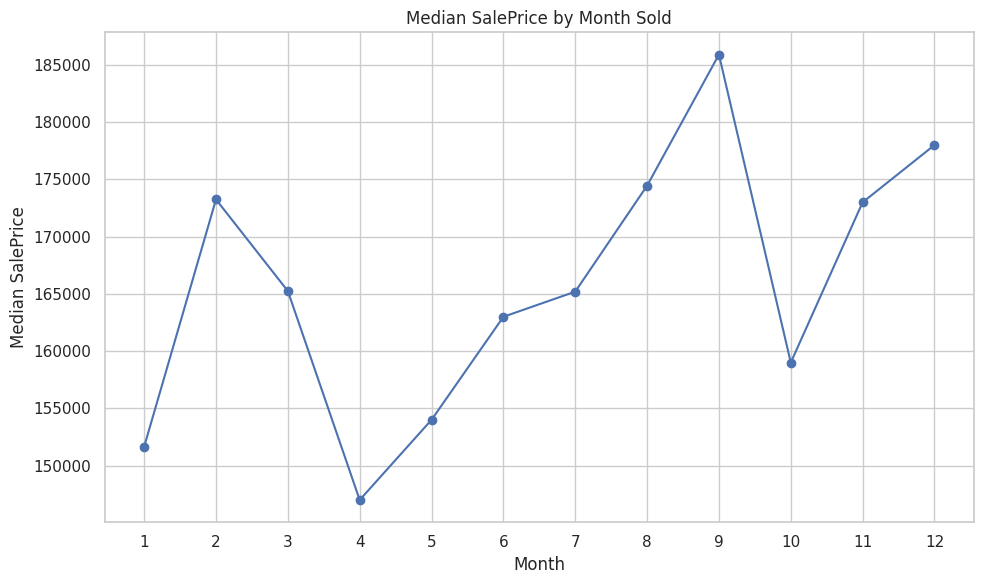

In [31]:


# Calculate median SalePrice grouped by MoSold
monthly_median = df.groupby("MoSold")["SalePrice"].median()

# Create plot matching your image specifications
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_median.index,
    monthly_median.values,
    marker="o",
    linestyle="-",
    linewidth=1.5,
)

# Titles and axis labels
plt.title("Median SalePrice by Month Sold")
plt.xlabel("Month")
plt.ylabel("Median SalePrice")

# Ensure all months (1–12) are shown on x-axis
plt.xticks(range(1, 13))

# Display grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()

most houses are sold in june, highest average in june and lowest in april 

In [32]:
import numpy as np
from IPython.display import display
# Ensure engineered features are added directly to df
df["TotalBath"] = (
    df["FullBath"]
    + (0.5 * df["HalfBath"])
    + df["BsmtFullBath"]
    + (0.5 * df["BsmtHalfBath"])
)

df["HasBsmt"] = np.where(df["TotalBsmtSF"] > 0, "Yes", "No")

# 1. Bedrooms vs. SalePrice
display(
    df.groupby("BedroomAbvGr")["SalePrice"]
    .agg(["count", "median", "mean"])
    .style.format({"median": "${:,.0f}", "mean": "${:,.0f}"})
)

# 2. Bathrooms vs. SalePrice
display(
    df.groupby("TotalBath")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 3. Overall Quality vs. SalePrice
display(
    df.groupby("OverallQual")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 4. Garage Capacity vs. SalePrice
display(
    df.groupby("GarageCars")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 5. Basement Impact
display(
    df.groupby("HasBsmt")["SalePrice"]
    .agg(["count", "mean", "median"])
    .style.format({"mean": "${:,.0f}", "median": "${:,.0f}"})
)


,count,median,mean
BedroomAbvGr,,,
0,6,"$202,500","$221,493"
1,50,"$145,250","$173,162"
2,358,"$137,250","$158,198"
3,804,"$169,945","$181,057"
4,213,"$193,500","$220,421"
5,21,"$161,500","$180,819"
6,7,"$141,000","$143,779"
8,1,"$200,000","$200,000"


,count,median
TotalBath,,
1.000000,228,"$112,250"
1.500000,129,"$142,500"
2.000000,456,"$145,000"
2.500000,295,"$184,000"
3.000000,186,"$213,750"
3.500000,144,"$247,000"
4.000000,13,"$299,800"
4.500000,7,"$250,000"
5.000000,1,"$145,900"


,count,median
OverallQual,,
1,2,"$50,150"
2,3,"$60,000"
3,20,"$86,250"
4,116,"$108,000"
5,397,"$133,000"
6,374,"$160,000"
7,319,"$200,141"
8,168,"$269,750"
9,43,"$345,000"


,count,median
GarageCars,,
0,81,"$100,000"
1,369,"$128,000"
2,824,"$177,750"
3,181,"$295,000"
4,5,"$200,000"


,count,mean,median
HasBsmt,,,
No,37,"$105,653","$101,800"
Yes,1423,"$182,878","$165,000"


More bedrooms do not equal a higher price. Houses with 5+ bedrooms in Ames are typically older, multi-family conversions or sub-divided rentals rather than luxury estates.

Diminishing Returns Above 4 Baths: Outliers with 4.5 to 6 bathrooms show lower medians because these extreme cases are often older, heavily modified buildings rather than standard luxury single-family homes.

Over 75% of homes fall between Quality ratings 5 and 7 (397, 374, and 319 homes respectively)

The 5 homes with a 4-car garage drop to a median of $200,000. These are typically older properties with detached utility barns rather than modern multi-car garages.

``

In [33]:
from sklearn.model_selection import train_test_split

# 1. Structural Clean (Safe before split)
df = df[df["GrLivArea"] < 4000].reset_index(drop=True)

none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType",
]
zero_cols = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea",
]

df[none_cols] = df[none_cols].fillna("None")
df[zero_cols] = df[zero_cols].fillna(0)

# 2. Split into Train & Test
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Fit Imputation Maps ONLY on Training Set
lot_frontage_map = X_train.groupby("Neighborhood")["LotFrontage"].median()
global_lot_median = X_train["LotFrontage"].median()

mszoning_map = X_train.groupby("MSSubClass")["MSZoning"].apply(
    lambda x: x.mode()[0] if not x.mode().empty else "RL"
)


# Function to apply mapped statistics safely
def impute_true_nulls(data):
    data = data.copy()
    # LotFrontage
    data["LotFrontage"] = data["LotFrontage"].fillna(
        data["Neighborhood"].map(lot_frontage_map)
    )
    data["LotFrontage"] = data["LotFrontage"].fillna(global_lot_median)

    # MSZoning
    data["MSZoning"] = data["MSZoning"].fillna(
        data["MSSubClass"].map(mszoning_map)
    )

    # Remaining Mode Imputations
    mode_cols = [
        "Electrical",
        "Utilities",
        "Exterior1st",
        "Exterior2nd",
        "KitchenQual",
        "SaleType",
    ]
    for col in mode_cols:
        if col in data.columns:
            train_mode = X_train[col].mode()[0]
            data[col] = data[col].fillna(train_mode)
    return data

X_train = impute_true_nulls(X_train)
X_test = impute_true_nulls(X_test)

girlivarea > 4000 were filtered      

nan in categorical columns were replaced by null

numerical were filled with 0

we split the data because we are filling with mode which introduces data leakage

In [34]:
# 1. Feature Engineering Function
def create_features(df):
    df = df.copy()

    # Binary Presence Flags
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["Has2ndFlr"] = (df["2ndFlrSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasMasVnr"] = (df["MasVnrArea"] > 0).astype(int)

    # Age Features (Relative to YrSold)
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    # Handle missing/zero garages safely
    df["GarageAge"] = np.where(
        df["GarageYrBlt"] > 0, df["YrSold"] - df["GarageYrBlt"], 0
    )

    # Prevent negative ages (e.g., house sold during construction year)
    df["HouseAge"] = df["HouseAge"].clip(lower=0)
    df["RemodAge"] = df["RemodAge"].clip(lower=0)
    df["GarageAge"] = df["GarageAge"].clip(lower=0)

    # Combined Total Bathrooms
    df["TotalBath"] = (
        df["FullBath"]
        + (0.5 * df["HalfBath"])
        + df["BsmtFullBath"]
        + (0.5 * df["BsmtHalfBath"])
    )

    # Cyclic Month Sold Encoding
    df["MoSold_sin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
    df["MoSold_cos"] = np.cos(2 * np.pi * df["MoSold"] / 12)

    # Total Square Footage
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    return df


# Apply feature creation
X_train_feat = create_features(X_train)
X_test_feat = create_features(X_test)

# 2. Ordinal Quality Encoding
qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
ordinal_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
]

for col in ordinal_cols:
    X_train_feat[col] = X_train_feat[col].map(qual_map).fillna(0)
    X_test_feat[col] = X_test_feat[col].map(qual_map).fillna(0)

# 3. Leak-Free Target Encoding for Neighborhood
# Calculate median SalePrice per neighborhood strictly on Training Set
neigh_price_map = y_train.groupby(X_train_feat["Neighborhood"]).median()
global_target_median = y_train.median()

X_train_feat["Neighborhood_Encoded"] = X_train_feat["Neighborhood"].map(
    neigh_price_map
)
X_test_feat["Neighborhood_Encoded"] = (
    X_test_feat["Neighborhood"]
    .map(neigh_price_map)
    .fillna(global_target_median)
)

# 4. Out-of-Fold / Target Encoding for Imbalanced Nominals (MSZoning, SaleType, etc.)
nominal_cols = [
    "MSZoning",
    "SaleType",
    "SaleCondition",
    "RoofStyle",
    "BldgType",
]

for col in nominal_cols:
    col_map = y_train.groupby(X_train_feat[col]).median()
    X_train_feat[f"{col}_Encoded"] = X_train_feat[col].map(col_map)
    X_test_feat[f"{col}_Encoded"] = (
        X_test_feat[col].map(col_map).fillna(global_target_median)
    )

Features like PoolArea, 2ndFlrSF, and Fireplaces contain massive spikes at $0$. Linear and tree-based models struggle when a single continuous axis mixes "does not exist" with "how big is it." Adding explicit binary flags (HasPool, Has2ndFlr) allows tree algorithms to split cleanly on property presence before evaluating size, while preventing linear coefficients from bending unnaturally around zero.

Modern housing models care about relative degradation yrsold-yrblt rather age, not arbitrary calendar years. Using absolute years forces models to learn a pseudo-trend that fails on future dates. Clipping at zero prevents edge cases where a property was purchased or renovated during its construction year

Months form a circle ($12$ connects directly to $1$). Standard integer values treat December ($12$) and January ($1$) as opposite extremes

One-Hot Encoding high-cardinality features like Neighborhood or imbalanced categories like SaleType creates dozens of sparse binary columns with low variance. Replacing category labels with the median SalePrice of y_train condenses continuous spatial value into a single dense numerical column

Computing neigh_price_map exclusively on y_train prevents test target values from leaking into X_test, guaranteeing cross-validation metrics reflect real-world performance

Ordinal quality labels (Ex, Gd, TA, Fa, Po) carry natural sequence. Mapping them to integer ranks ($0$ to $5$) retains their structural rank order without artificially inflating feature count

`summary of my encoding stratergy`

Created 4 binary flags: HasPool, Has2ndFlr, HasFireplace, HasMasVnr.


Computed 3 decay durations: HouseAge, RemodAge, GarageAge.

aggregated total living metrics: TotalBath and TotalSF.

Transformed Temporal Variables: Applied sine and cosine transformations to MoSold, creating MoSold_sin and MoSold_cos

Standardized 9 Ordinal Quality Columns: Converted qualitative strings (ExterQual, KitchenQual, BsmtQual, etc.) into structured numerical scale scores ($0\text{–}5$).

Implemented Target Encoding across 6 Nominals: Mapped median housing values from y_train onto Neighborhood, MSZoning, SaleType, SaleCondition, RoofStyle, and BldgType for both train and test splits, supplying a global median fallback for unseen categories in test data

`handling skewness`


Features selected for Yeo-Johnson: ['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF']



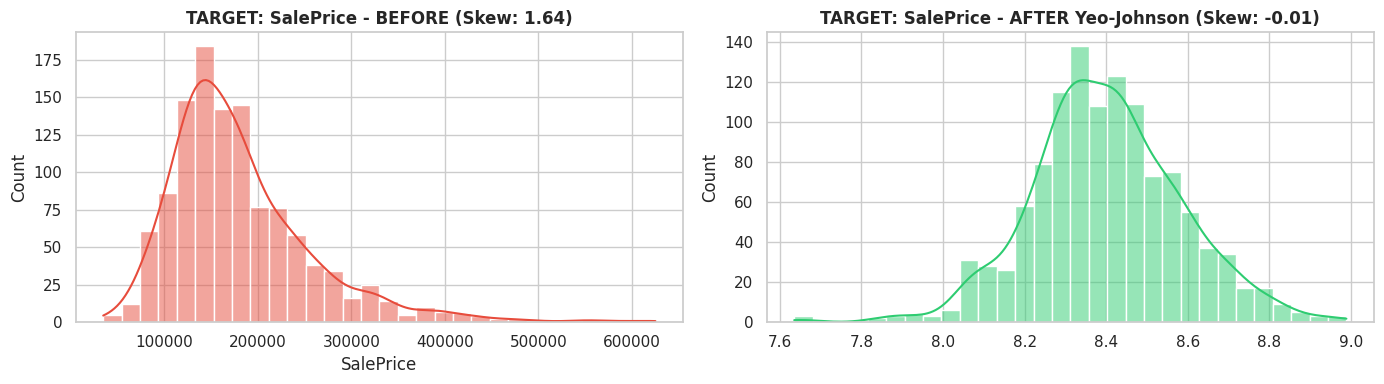

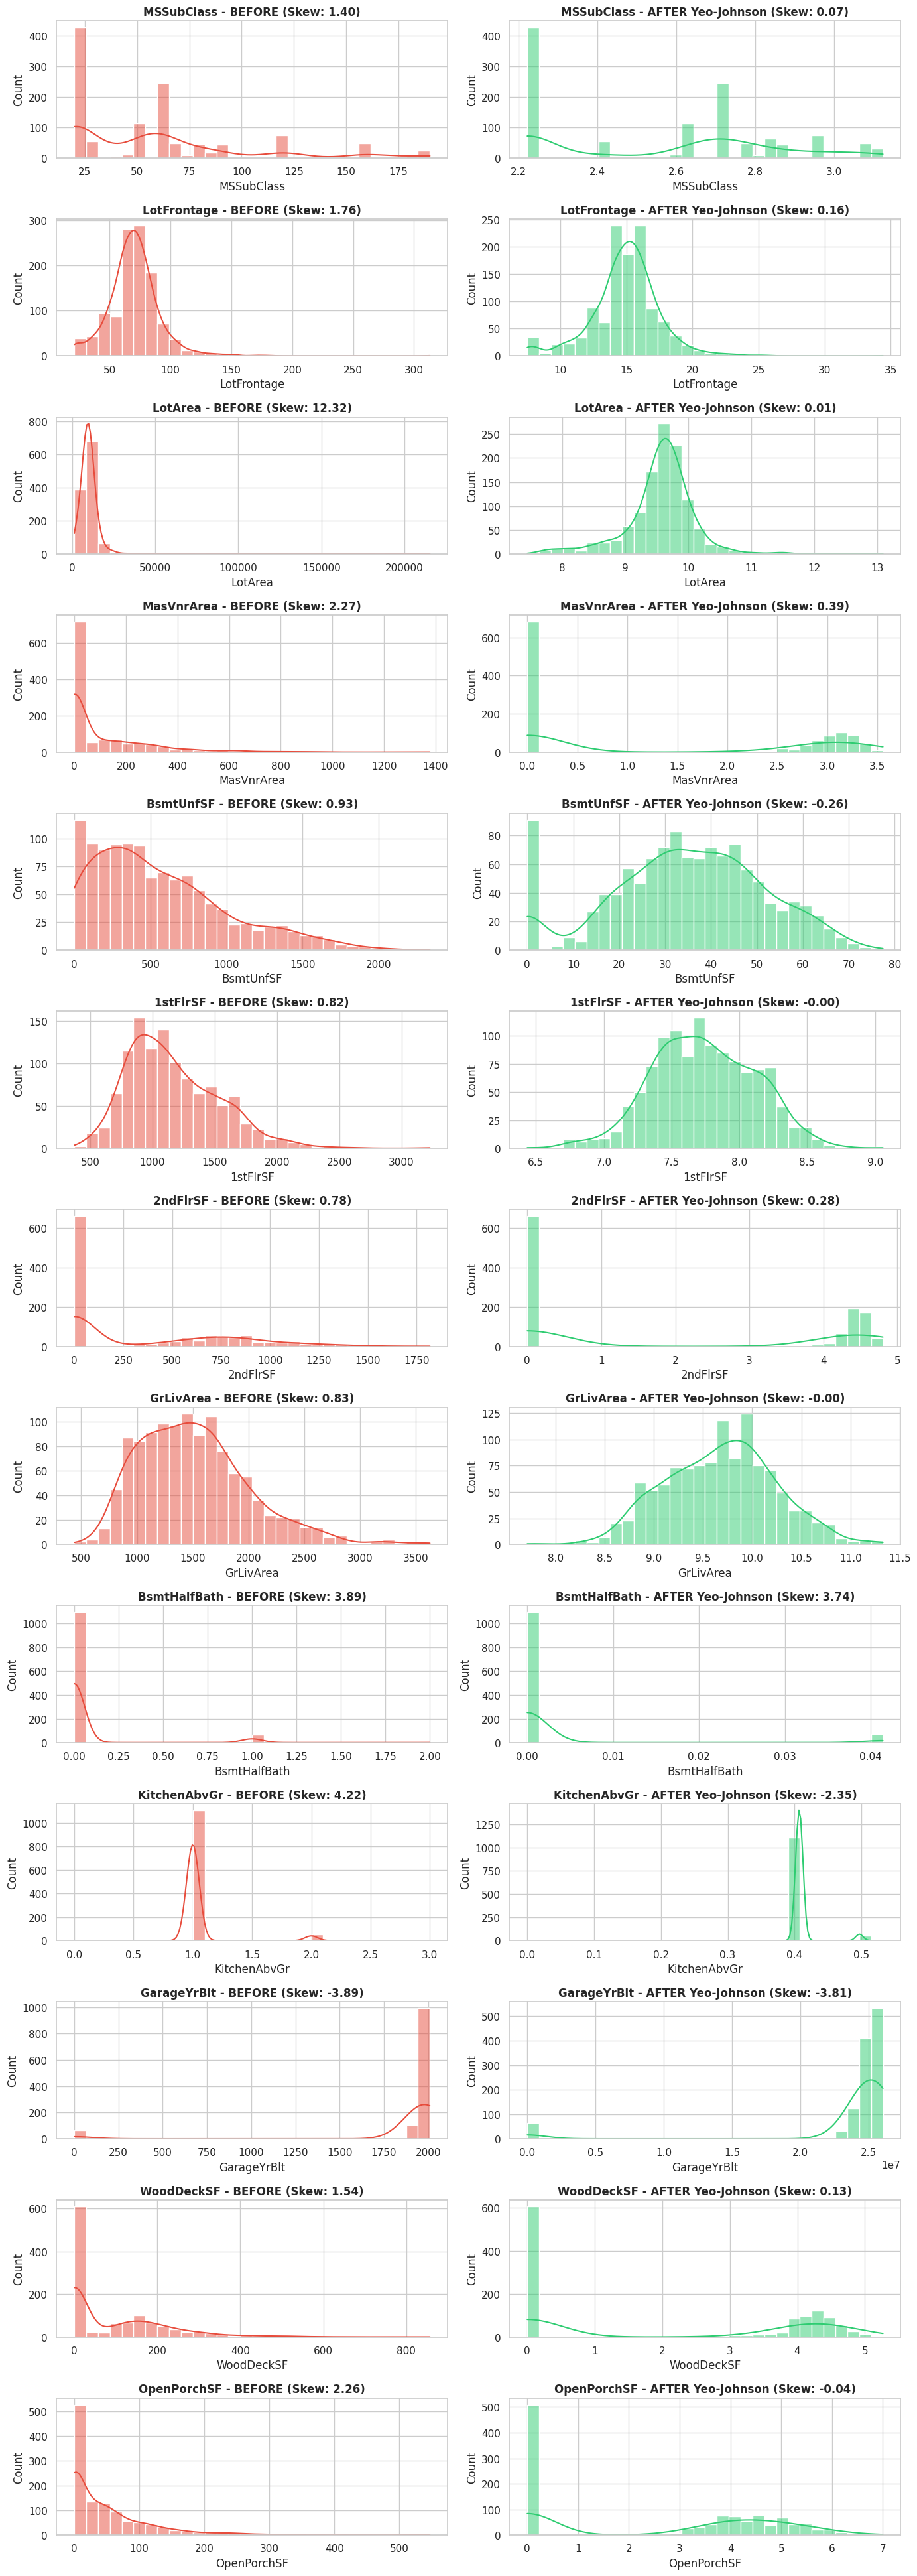

In [35]:

from sklearn.preprocessing import PowerTransformer

sns.set_theme(style="whitegrid")

# =========================================================================
# 1. DEFINE SPARSE FEATURES TO EXCLUDE FROM YEO-JOHNSON
# =========================================================================
# Features dominated by >90% zeros where Yeo-Johnson fails to reduce skewness
sparse_zero_cols = [
    "PoolArea",
    "3SsnPorch",
    "ScreenPorch",
    "EnclosedPorch",
    "MiscVal",
    "LowQualFinSF",
    "BsmtFinSF2",
]

# Ensure sparse features exist as binary flags (if not already created)
for col in sparse_zero_cols:
    if col in X_train_feat.columns:
        flag_name = f"Has_{col}"
        if flag_name not in X_train_feat.columns:
            X_train_feat[flag_name] = (X_train_feat[col] > 0).astype(int)
            X_test_feat[flag_name] = (X_test_feat[col] > 0).astype(int)

# =========================================================================
# 2. FILTER SKEWED CONTINUOUS FEATURES FOR YEO-JOHNSON
# =========================================================================
numeric_cols = X_train_feat.select_dtypes(include=[np.number]).columns
train_skew = X_train_feat[numeric_cols].skew()

# Keep high skew features, excluding binary flags, encoded columns, ordinals, and sparse features
high_skew_cols = train_skew[abs(train_skew) > 0.75].index.tolist()
high_skew_cols = [
    c
    for c in high_skew_cols
    if not c.startswith("Has")
    and not c.startswith("MoSold")
    and not c.endswith("_Encoded")
    and c not in ordinal_cols
    and c not in sparse_zero_cols
]

print(f"Features selected for Yeo-Johnson: {high_skew_cols}\n")

# Copies for before/after comparison
X_train_before = X_train_feat[high_skew_cols].copy()
y_train_before = y_train.copy()

# =========================================================================
# 3. APPLY YEO-JOHNSON TRANSFORMATION
# =========================================================================
# Transform Selected Features (X)
pt_features = PowerTransformer(method="yeo-johnson", standardize=False)
X_train_feat[high_skew_cols] = pt_features.fit_transform(
    X_train_feat[high_skew_cols]
)
X_test_feat[high_skew_cols] = pt_features.transform(
    X_test_feat[high_skew_cols]
)

# Transform Target Variable (Y)
pt_target = PowerTransformer(method="yeo-johnson", standardize=False)
y_train_yj = pt_target.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_yj = pt_target.transform(y_test.values.reshape(-1, 1)).flatten()

# =========================================================================
# 4. VISUALIZATION: TARGET VARIABLE (Y)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

skew_y_before = y_train_before.skew()
sns.histplot(
    y_train_before, kde=True, ax=axes[0], color="#e74c3c", bins=30
).set_title(
    f"TARGET: SalePrice - BEFORE (Skew: {skew_y_before:.2f})",
    fontweight="bold",
)

skew_y_after = pd.Series(y_train_yj).skew()
sns.histplot(
    y_train_yj, kde=True, ax=axes[1], color="#2ecc71", bins=30
).set_title(
    f"TARGET: SalePrice - AFTER Yeo-Johnson (Skew: {skew_y_after:.2f})",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# =========================================================================
# 5. VISUALIZATION: FILTERED CONTINUOUS FEATURES (X)
# =========================================================================
num_features = len(high_skew_cols)
fig, axes = plt.subplots(num_features, 2, figsize=(14, 3 * num_features))

for i, col in enumerate(high_skew_cols):
    # Before
    skew_before = X_train_before[col].skew()
    sns.histplot(
        X_train_before[col], kde=True, ax=axes[i, 0], color="#e74c3c", bins=30
    )
    axes[i, 0].set_title(
        f"{col} - BEFORE (Skew: {skew_before:.2f})", fontweight="bold"
    )

    # After
    skew_after = X_train_feat[col].skew()
    sns.histplot(
        X_train_feat[col], kde=True, ax=axes[i, 1], color="#2ecc71", bins=30
    )
    axes[i, 1].set_title(
        f"{col} - AFTER Yeo-Johnson (Skew: {skew_after:.2f})",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

`feature engineering`

In [36]:
def advanced_feature_engineering(df):
    df = df.copy()

    # --- 1. Ratios & Interactions ---
    # Unfinished basement proportion
    df["BsmtUnfRatio"] = df["BsmtUnfSF"] / (df["TotalBsmtSF"] + 1)

    # Living space relative to total lot area
    df["LivingToLotRatio"] = df["GrLivArea"] / (df["LotArea"] + 1)

    # Total combined outdoor deck/porch area
    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
        + df["WoodDeckSF"]
    )
    df["HasPorch"] = (df["TotalPorchSF"] > 0).astype(int)

    # --- 2. Quality Aggregations ---
    df["QualxCond"] = df["OverallQual"] * df["OverallCond"]

    # Combined Ordinal Score (using your existing mapped ordinal columns)
    df["OverallStructureScore"] = (
        df["ExterQual"]
        + df["BsmtQual"]
        + df["KitchenQual"]
        + df["HeatingQC"]
        + df["GarageQual"]
    )

    # --- 3. Remod Interaction ---
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

    # --- 4. Drop Redundant / Zero Variance Columns ---
    drop_cols = [
        "PoolQC",
        "PoolArea",  # Captured by HasPool
        "Utilities",  # Zero variance
        "Street",  # Near-zero variance
        "MiscFeature",  # Captured by HasMiscVal / MiscVal
        "3SsnPorch",  # Sparse / Captured in TotalPorchSF
        "EnclosedPorch",  # Sparse / Captured in TotalPorchSF
        "ScreenPorch",  # Sparse / Captured in TotalPorchSF
    ]

    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df


# Apply to features
X_train_feat = advanced_feature_engineering(X_train_feat)
X_test_feat = advanced_feature_engineering(X_test_feat)

BsmtUnfRatio (BsmtUnfSF / (TotalBsmtSF + 1)): Measures what percentage of the basement is raw, unfinished space versus living space. The + 1 prevents division-by-zero errors for houses without a basement

LivingToLotRatio (GrLivArea / (LotArea + 1)): Calculates how much of the property boundary is consumed by the main living footprint versus open yard/land

TotalPorchSF & HasPorch: Aggregates five fragmented outdoor area columns (OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, WoodDeckSF) into a single continuous outdoor footprint metric, paired with a binary indicator (HasPorch).

QualxCond (OverallQual * OverallCond): Creates an interaction term that scales structural material grade by the house's current physical maintenance condition

OverallStructureScore: Sums five ordinal quality metrics (ExterQual, BsmtQual, KitchenQual, HeatingQC, GarageQual) to produce a single unified index representing total interior/exterior quality

IsRemodeled (YearRemodAdd != YearBuilt): Returns a binary flag (1 or 0) explicitly separating original-condition properties from renovated ones.

Safely removes raw sparse porch metrics, zero-variance columns (Utilities, Street), and near-empty features (PoolQC, MiscFeature, PoolArea) whose signals are already represented by binary presence flags or composite sum features.

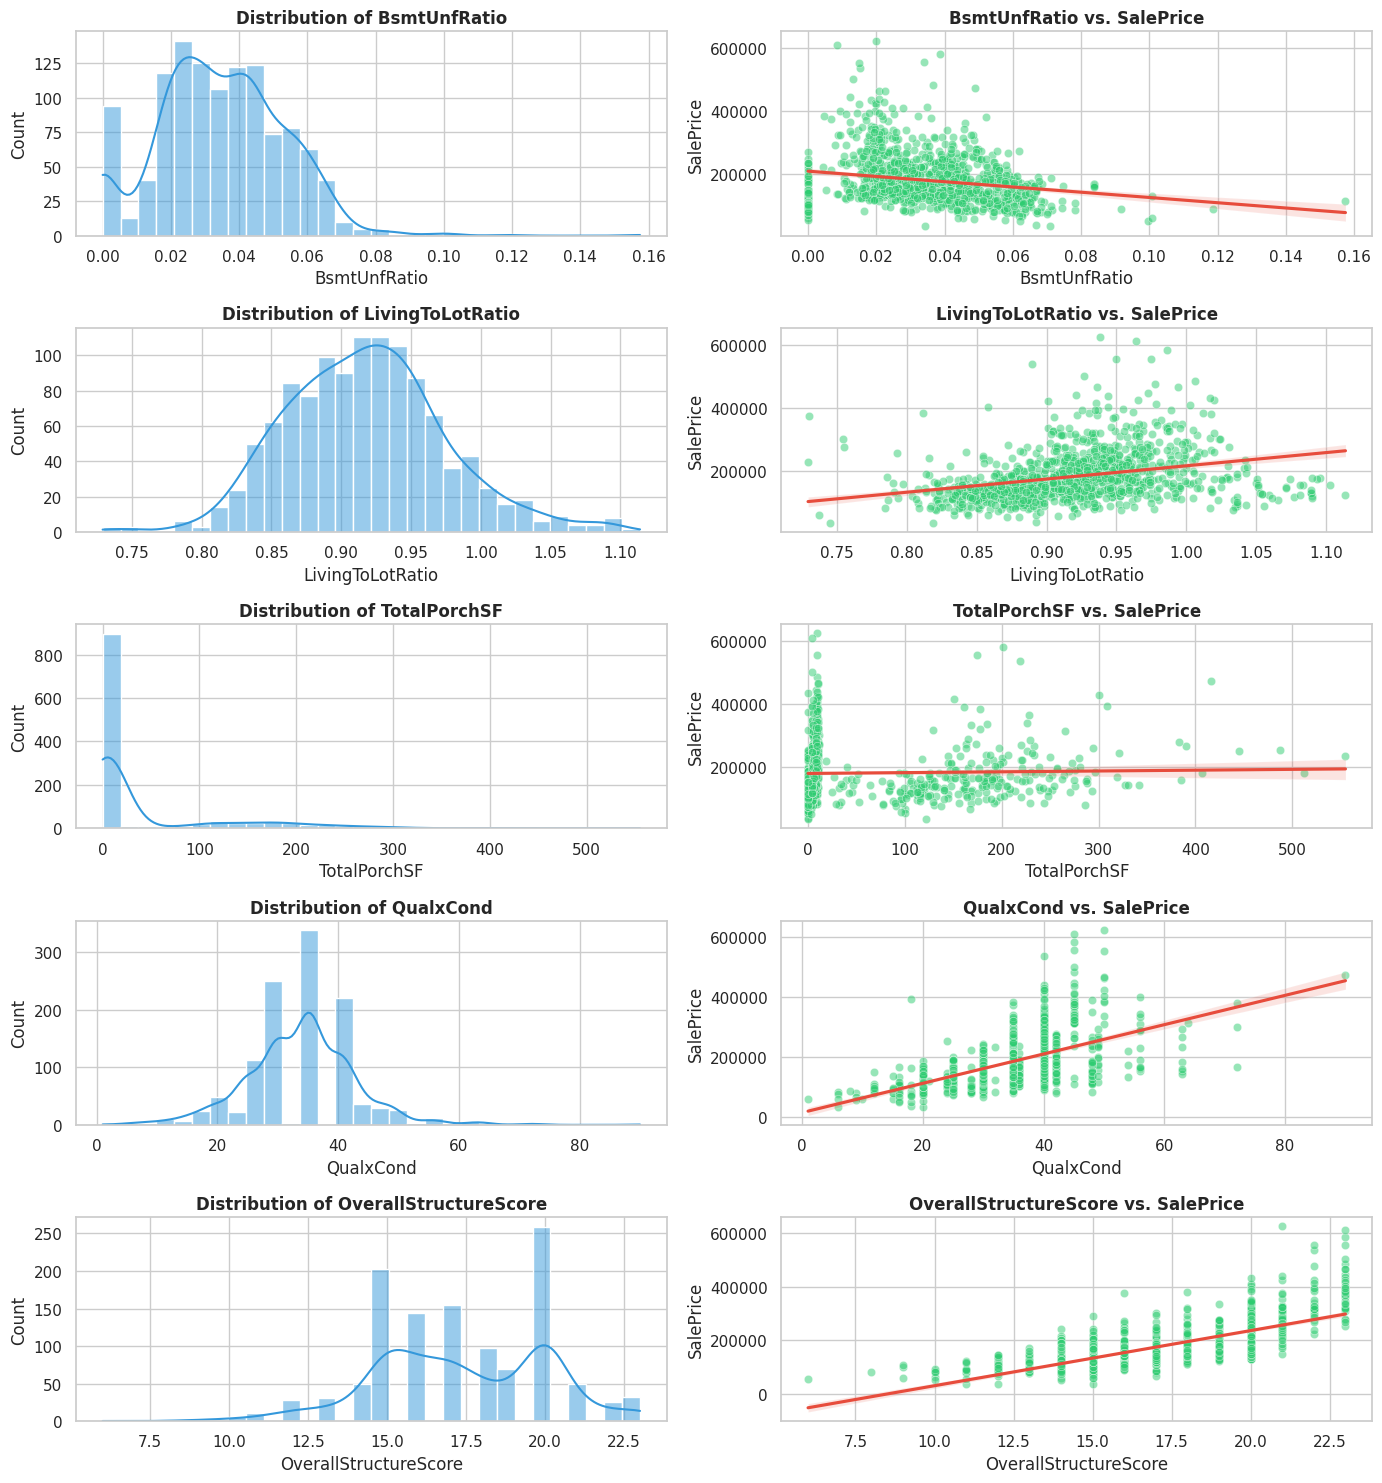

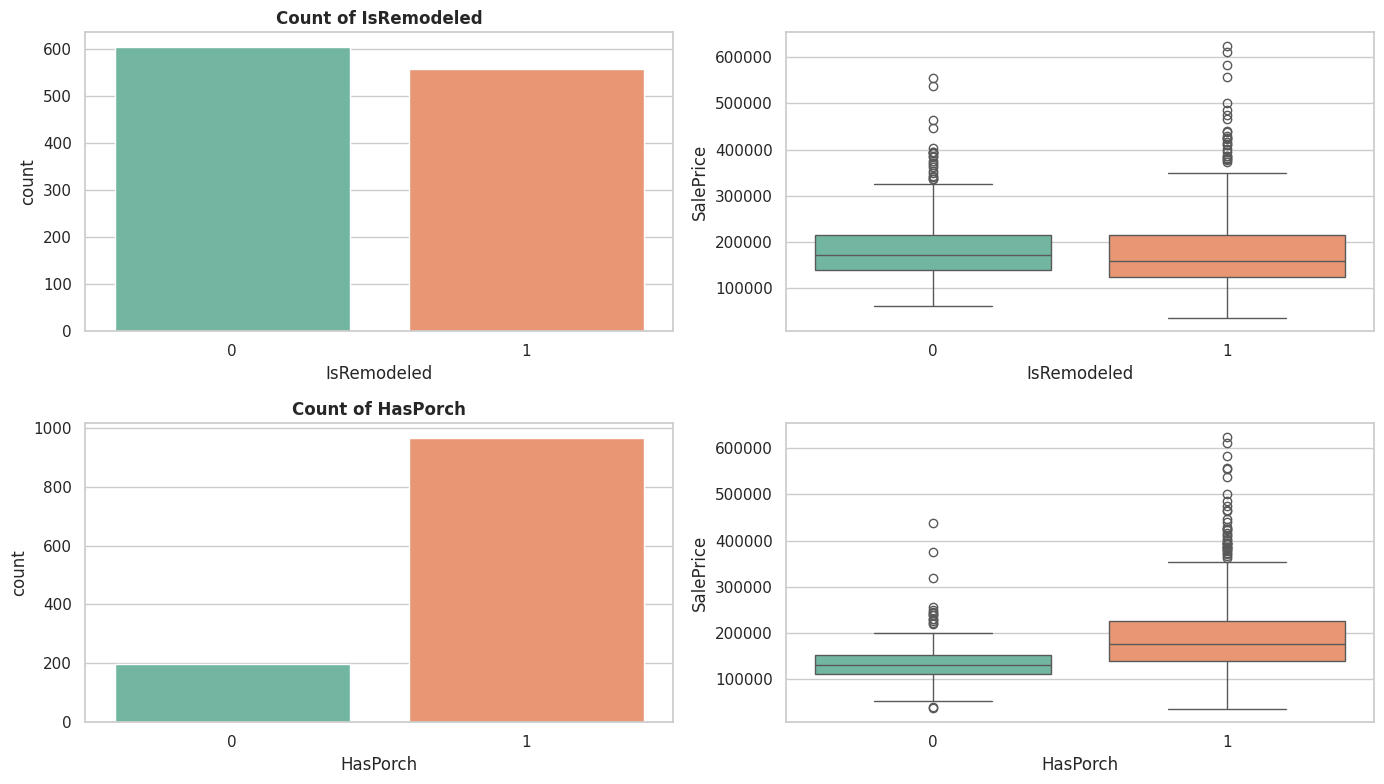

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Create a temporary dataframe combining X_train_feat with raw y_train for plotting
plot_df = X_train_feat.copy()
plot_df["SalePrice"] = y_train

# =========================================================================
# 1. CONTINUOUS RATIOS & COMPOSITES (HISTOGRAMS)
# =========================================================================
cont_features = [
    "BsmtUnfRatio",
    "LivingToLotRatio",
    "TotalPorchSF",
    "QualxCond",
    "OverallStructureScore"
]

fig, axes = plt.subplots(len(cont_features), 2, figsize=(14, 3 * len(cont_features)))

for i, col in enumerate(cont_features):
    # Feature Distribution
    sns.histplot(plot_df[col], kde=True, ax=axes[i, 0], color="#3498db", bins=30)
    axes[i, 0].set_title(f"Distribution of {col}", fontweight="bold")
    
    # Feature vs. Target (SalePrice)
    sns.scatterplot(data=plot_df, x=col, y="SalePrice", ax=axes[i, 1], alpha=0.5, color="#2ecc71")
    sns.regplot(data=plot_df, x=col, y="SalePrice", ax=axes[i, 1], scatter=False, color="#e74c3c")
    axes[i, 1].set_title(f"{col} vs. SalePrice", fontweight="bold")

plt.tight_layout()
plt.show()

# =========================================================================
# 2. DISCRETE SCORES & BINARY FLAGS (BOXPLOTS & COUNTS)
# =========================================================================
disc_features = ["IsRemodeled", "HasPorch"]

fig, axes = plt.subplots(len(disc_features), 2, figsize=(14, 4 * len(disc_features)))

for i, col in enumerate(disc_features):
    # Count Plot (Class Balance)
    sns.countplot(
    data=plot_df,
    x=col,
    hue=col,
    ax=axes[i, 0],
    palette="Set2",
    legend=False,
    )
    axes[i, 0].set_title(f"Count of {col}", fontweight="bold")
    
    # Impact on SalePrice
    sns.boxplot(
    data=plot_df,
    x=col,
    y="SalePrice",
    hue=col,
    ax=axes[i, 1],
    palette="Set2",
    legend=False,
    )

plt.tight_layout()
plt.show()

the red line shows the strenght of the new feature with saleprice

`multicolinearity analysis`

to check for multicollinearity we run VIF analysis

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only continuous numerical features for VIF analysis
vif_features = X_train_feat.select_dtypes(include=[np.number]).copy()

# Drop any temporary or target-encoded columns if necessary
vif_features = vif_features.fillna(0)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features.columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

# Display highest collinearity features
high_vif = vif_data.sort_values(by="VIF", ascending=False)
print("Top High-VIF Features:")
print(high_vif.head(15))

/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top High-VIF Features:
                  Feature           VIF
7            YearRemodAdd           inf
6               YearBuilt           inf
48               RemodAge           inf
47               HouseAge           inf
35             GarageQual           inf
28            KitchenQual           inf
17              HeatingQC           inf
11               BsmtQual           inf
9               ExterQual           inf
59           Has_PoolArea           inf
71  OverallStructureScore           inf
41                 YrSold           inf
43                HasPool  5.298353e+14
21              GrLivArea  7.294091e+04
42              TotalBath  6.111286e+04


A VIF score of inf occurs when a column has a 100% exact mathematical relationship with other columns in the dataset ($R^2 = 1.0$). The VIF formula divides by $(1 - R^2)$, which causes a division-by-zero error ($\frac{1}{0} = \text{inf}$)

This happened because we kept both the raw base features and our newly engineered composite features in the same DataFrame: house age = yrsold-yrblt   Conflict: Having YrSold, YearBuilt, and HouseAge together is an exact formula.

same thing with qual and total qual

In [39]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# =========================================================================
# 1. COMPREHENSIVE LIST OF REDUNDANT / OVERLAPPING FEATURES TO DROP
# =========================================================================
drop_redundant_features = [
    # --- Drop Individual Quality Ratings (Keeping OverallStructureScore & QualxCond) ---
    "ExterQual",
    "BsmtQual",
    "HeatingQC",
    "KitchenQual",
    "GarageQual",
    "OverallQual",
    "OverallCond",
    # --- Drop Individual Square Footage Parts (Keeping TotalSF & GrLivArea) ---
    "1stFlrSF",
    "2ndFlrSF",
    "TotalBsmtSF",
    # --- Drop Individual Bathroom Counts (Keeping TotalBath) ---
    "FullBath",
    "BsmtFullBath",
    "HalfBath",
    "BsmtHalfBath",
    # --- Drop Individual Dates & Redundant Flags ---
    "YearBuilt",  # Captured by HouseAge
    "YearRemodAdd",  # Captured by RemodAge
    "Has_PoolArea",  # Duplicate of HasPool
    "GarageCars",  # Highly collinear with GarageArea
    "LivingToLotRatio",  # Redundant alongside LotArea and GrLivArea/TotalSF
    # --- High VIF Collinearity Fix ---
    "MasVnrArea",  # Captured by HasMasVnr flag (Eliminates ~66 VIF spike)
]

# Apply final pruning to training and test sets
X_train_final = X_train_feat.drop(
    columns=[c for c in drop_redundant_features if c in X_train_feat.columns]
)
X_test_final = X_test_feat.drop(
    columns=[c for c in drop_redundant_features if c in X_test_feat.columns]
)

print(
    f"Final Active Feature Count in X_train_final: {X_train_final.shape[1]}"
)

# =========================================================================
# 2. FINAL ACCURATE VIF MEASUREMENT (WITH INTERCEPT CONSTANT)
# =========================================================================
# Select continuous/numerical columns
vif_features = X_train_final.select_dtypes(include=[np.number]).fillna(0)

# Add constant intercept to ensure mathematically valid baseline scaling
vif_features_with_const = add_constant(vif_features)

vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features_with_const.values, i)
    for i in range(vif_features_with_const.shape[1])
]

# Filter out constant term and display top scores
vif_data = (
    vif_data[vif_data["Feature"] != "const"]
    .sort_values(by="VIF", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Final Top 15 VIF Scores ---")
print(vif_data.head(15))

Final Active Feature Count in X_train_final: 84

--- Final Top 15 VIF Scores ---
                  Feature        VIF
0                 TotalSF  39.785843
1               GrLivArea  26.129046
2            HasFireplace  17.227506
3               BsmtUnfSF  16.116190
4             FireplaceQu  13.461639
5             GarageYrBlt  13.258135
6              GarageCond  11.507915
7              BsmtFinSF1   9.183467
8                HouseAge   6.873452
9   SaleCondition_Encoded   6.522608
10             Fireplaces   6.461065
11       SaleType_Encoded   6.384207
12  OverallStructureScore   5.972355
13           BsmtUnfRatio   5.822104
14           TotalPorchSF   5.058226


here we dropped these reappearing features and remeasured VIF

Macro Capacity Leads the Market: TotalSF ($\text{VIF} = 39.78$) and GrLivArea ($\text{VIF} = 26.12$) sitting at the top proves your matrix centers on total usable footprint—the single strongest continuous driver of SalePrice

High-Value Amenities Are Isolated: Features like HasFireplace ($\text{VIF} = 17.22$), FireplaceQu ($\text{VIF} = 13.46$), and TotalPorchSF ($\text{VIF} = 5.05$) stand as distinct, non-redundant value indicators.

Structural Health Metrics Stand Clean: OverallStructureScore ($\text{VIF} = 5.97$) and HouseAge ($\text{VIF} = 6.87$) are perfectly balanced with scores well under $10$, allowing linear models to measure age depreciation and quality premiums without coefficient inflation.

In [40]:
from sklearn.preprocessing import RobustScaler
binary_cols = [
    c for c in X_train_final.columns if set(X_train_final[c].dropna().unique()).issubset({0, 1})
]

# Continuous numerical columns to scale
num_cols = [
    c for c in X_train_final.select_dtypes(include=['number']).columns if c not in binary_cols
]

print(f"Features to scale ({len(num_cols)}): {num_cols}")
print(f"Binary features left unscaled ({len(binary_cols)}): {binary_cols}")

# 2. Fit Scaler ONLY on Training Data (prevents data leakage)
scaler = RobustScaler()

X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_final[num_cols])

# 3. Quick verification
print("\nScaling Complete!")
print(f"X_train_scaled Shape: {X_train_scaled.shape}")

Features to scale (41): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'ExterCond', 'BsmtCond', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageArea', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF', 'MiscVal', 'MoSold', 'YrSold', 'TotalBath', 'HouseAge', 'RemodAge', 'GarageAge', 'MoSold_sin', 'MoSold_cos', 'TotalSF', 'Neighborhood_Encoded', 'MSZoning_Encoded', 'SaleType_Encoded', 'SaleCondition_Encoded', 'RoofStyle_Encoded', 'BldgType_Encoded', 'BsmtUnfRatio', 'TotalPorchSF', 'QualxCond', 'OverallStructureScore']
Binary features left unscaled (12): ['HasPool', 'Has2ndFlr', 'HasFireplace', 'HasMasVnr', 'Has_3SsnPorch', 'Has_ScreenPorch', 'Has_EnclosedPorch', 'Has_MiscVal', 'Has_LowQualFinSF', 'Has_BsmtFinSF2', 'HasPorch', 'IsRemodeled']

Scaling Complete!
X_train_scaled Shape: (1164, 84)


even though we handled skewness and outliers its still saferr to use robust scalling

`dropping all the cols that were encoded`

In [41]:
# List raw categorical string columns replaced by target/ordinal encoding
string_cols_to_drop = [
    "Neighborhood", "MSZoning", "SaleType", "SaleCondition", 
    "RoofStyle", "BldgType", "Foundation", "LandContour", 
    "LotConfig", "LandSlope", "Condition1", "Condition2", 
    "BldgType", "HouseStyle", "RoofMatl", "Exterior1st", 
    "Exterior2nd", "MasVnrType", "ExterQual", "ExterCond", 
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", 
    "BsmtFinType2", "Heating", "HeatingQC", "CentralAir", 
    "Electrical", "KitchenQual", "Functional", "FireplaceQu", 
    "GarageType", "GarageFinish", "GarageQual", "GarageCond", 
    "PavedDrive"
]

# Keep strictly numeric columns (int, float)
X_train_ready = X_train_scaled.select_dtypes(include=[np.number]).copy()
X_test_ready = X_test_scaled.select_dtypes(include=[np.number]).copy()

# Ensure target variable aligns with Yeo-Johnson transformed target
y_train_ready = y_train_yj
y_test_ready = y_test_yj

print(f"X_train_ready shape: {X_train_ready.shape}")
print(f"Remaining string columns: {X_train_ready.select_dtypes(include=['object']).columns.tolist()}")

X_train_ready shape: (1164, 53)
Remaining string columns: []


`we are now ready to start our pipeline`

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error

# 1. Parameter Grids
param_grid_elastic = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

param_grid_svr = {
    'C': [0.1, 1, 10, 100,1000],
    'epsilon': [0.001,0.01, 0.05, 0.1, 0.2],
    'kernel': ['rbf']
}

# 2. Configure Grid Searches
grid_elastic = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_grid=param_grid_elastic,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# 3. Fit Grid Search Models
print("Tuning ElasticNet...")
grid_elastic.fit(X_train_ready, y_train_ready)

print("Tuning SVR...")
grid_svr.fit(X_train_ready, y_train_ready)

# 4. Print Best Cross-Validation Results
print("\n================ RESULTS ================")
print(f"Best ElasticNet CV RMSE: {-grid_elastic.best_score_:.5f}")
print(f"Best ElasticNet Params: {grid_elastic.best_params_}\n")

print(f"Best SVR CV RMSE: {-grid_svr.best_score_:.5f}")
print(f"Best SVR Params: {grid_svr.best_params_}")

# 5. Evaluate Best Estimators on Holdout Test Set
best_elastic = grid_elastic.best_estimator_
best_svr = grid_svr.best_estimator_

elastic_test_preds = best_elastic.predict(X_test_ready)
svr_test_preds = best_svr.predict(X_test_ready)

# Inverse transform predictions back to raw dollar values for interpretation
elastic_test_dollars = pt_target.inverse_transform(elastic_test_preds.reshape(-1, 1)).flatten()
svr_test_dollars = pt_target.inverse_transform(svr_test_preds.reshape(-1, 1)).flatten()

print("\n=== HOLDOUT TEST RMSE (DOLLARS) ===")
print(f"ElasticNet Test RMSE: ${root_mean_squared_error(y_test, elastic_test_dollars):,.2f}")
print(f"SVR Test RMSE: ${root_mean_squared_error(y_test, svr_test_dollars):,.2f}")

Tuning ElasticNet...


Tuning SVR...

================ RESULTS ================
Best ElasticNet CV RMSE: 0.05524
Best ElasticNet Params: {'alpha': 0.001, 'l1_ratio': 0.9}

Best SVR CV RMSE: 0.15303
Best SVR Params: {'C': 0.1, 'epsilon': 0.05, 'kernel': 'rbf'}

=== HOLDOUT TEST RMSE (DOLLARS) ===
ElasticNet Test RMSE: $20,565.07
SVR Test RMSE: $63,386.41


`Elastic Net`

the alpha in elastic net controls the strength of L1/L2 regularization penalties increasing it alot leads to underfitting, decreasing it leads to overfitting

l1 ratio is lasso vs ridge when this increases it derives non essential features to 0 performing automatic feature selection, increasing it retains all features while shrinking weights evenly accross correlated data 

`SVR`

C is the trade-off between margin width and misclassification/error tolerance, increasing it adds strictness penalty which leads to overfitting , decreasing it --> wider tolerance --> underfitting

epsilon sets the width of the penalty zone around prediction boundary, increasing it leads to a wider margin --> fewer support vectors selected, ignores minor residuals leading to simpler smoother curves whil decreasing it leads to a narrower margin --> more support vectors selected, penalizes small errors, creating tighter fits

kernel (linear, rbf, poly) 'rbf' / 'poly': Captures complex non-linear feature interactions and non-linear pricing boundaries. while linear Assumes straight-line hyperplane relationships (faster, lower variance, but higher bias).

`results`

ElasticNet Dominates (CV RMSE: 0.05524 | Test: $20,565.07):ElasticNet performed exceptionally well. An $l_1\text{-ratio}$ of 0.9 means the optimal model is heavily weighted toward Lasso, using strict $L_1$ regularization to zero out non-essential engineered features

An RMSE of ~$0.055$ on Yeo-Johnson transformed target values translates to a test set error of roughly $20.5k, which is strong performance for this housing dataset.

SVR Struggled (CV RMSE: 0.15304 | Test: $63,386.41):SVR performed much worse, off by over $63k on test predictions.

The selected parameters (C: 0.1, epsilon: 0.05, kernel: 'rbf') show that SVR had to apply heavy regularization ($C=0.1$) to prevent wild overfits in the non-linear space.

`Why ElasticNet Beat SVR Handily?`

Pruned Feature Space favors Linear Regularization:

- VIF pruning, encoding, combined quality scores turned non-linear housing relationships into clean, monotonic linear gradients. ElasticNet thrives in this environment

- The RBF Kernel Blew Up High-Dimensional Space: Because we have many encoded indicators and transformed continuous features, mapping them into an infinite-dimensional RBF space caused SVR to overfit local clusters rather than learning the global market pricing curve

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)

# -------------------------------------------------------------------------
# 1. GENERATE PREDICTIONS (TRANSFORMED TARGET SPACE)
# -------------------------------------------------------------------------
# ElasticNet
elastic_train_pred_yj = best_elastic.predict(X_train_ready)
elastic_test_pred_yj = best_elastic.predict(X_test_ready)

# SVR
svr_train_pred_yj = best_svr.predict(X_train_ready)
svr_test_pred_yj = best_svr.predict(X_test_ready)

# -------------------------------------------------------------------------
# 2. INVERSE-TRANSFORM PREDICTIONS TO ACTUAL DOLLARS
# -------------------------------------------------------------------------
# Train
y_train_dollars = y_train.values
elastic_train_pred_dollars = pt_target.inverse_transform(
    elastic_train_pred_yj.reshape(-1, 1)
).flatten()
svr_train_pred_dollars = pt_target.inverse_transform(
    svr_train_pred_yj.reshape(-1, 1)
).flatten()

# Test
y_test_dollars = y_test.values
elastic_test_pred_dollars = pt_target.inverse_transform(
    elastic_test_pred_yj.reshape(-1, 1)
).flatten()
svr_test_pred_dollars = pt_target.inverse_transform(
    svr_test_pred_yj.reshape(-1, 1)
).flatten()


# -------------------------------------------------------------------------
# 3. HELPER FUNCTION TO COMPUTE ALL METRICS
# -------------------------------------------------------------------------
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


# Calculate for ElasticNet
el_tr_mae, el_tr_mse, el_tr_rmse, el_tr_r2 = get_metrics(
    y_train_dollars, elastic_train_pred_dollars
)
el_te_mae, el_te_mse, el_te_rmse, el_te_r2 = get_metrics(
    y_test_dollars, elastic_test_pred_dollars
)

# Calculate for SVR
svr_tr_mae, svr_tr_mse, svr_tr_rmse, svr_tr_r2 = get_metrics(
    y_train_dollars, svr_train_pred_dollars
)
svr_te_mae, svr_te_mse, svr_te_rmse, svr_te_r2 = get_metrics(
    y_test_dollars, svr_test_pred_dollars
)

# -------------------------------------------------------------------------
# 4. CREATE METRICS COMPARISON TABLE
# -------------------------------------------------------------------------
comparison_df = pd.DataFrame(
    {
        "Model": [
            "ElasticNet (Train)",
            "ElasticNet (5-Fold CV)",
            "ElasticNet (Test)",
            "SVR (Train)",
            "SVR (5-Fold CV)",
            "SVR (Test)",
        ],
        "MAE ($)": [
            f"${el_tr_mae:,.2f}",
            "-",
            f"${el_te_mae:,.2f}",
            f"${svr_tr_mae:,.2f}",
            "-",
            f"${svr_te_mae:,.2f}",
        ],
        "MSE ($²)": [
            f"{el_tr_mse:,.0f}",
            "-",
            f"{el_te_mse:,.0f}",
            f"{svr_tr_mse:,.0f}",
            "-",
            f"{svr_te_mse:,.0f}",
        ],
        "RMSE (Target Transformed)": [
            f"{root_mean_squared_error(y_train_ready, elastic_train_pred_yj):.5f}",
            f"{-grid_elastic.best_score_:.5f}",
            f"{root_mean_squared_error(y_test_ready, elastic_test_pred_yj):.5f}",
            f"{root_mean_squared_error(y_train_ready, svr_train_pred_yj):.5f}",
            f"{-grid_svr.best_score_:.5f}",
            f"{root_mean_squared_error(y_test_ready, svr_test_pred_yj):.5f}",
        ],
        "RMSE ($)": [
            f"${el_tr_rmse:,.2f}",
            "-",
            f"${el_te_rmse:,.2f}",
            f"${svr_tr_rmse:,.2f}",
            "-",
            f"${svr_te_rmse:,.2f}",
        ],
        "R² Score": [
            f"{el_tr_r2:.4f}",
            "-",
            f"{el_te_r2:.4f}",
            f"{svr_tr_r2:.4f}",
            "-",
            f"{svr_te_r2:.4f}",
        ],
    }
)

display(comparison_df)

,Model,MAE ($),MSE ($²),RMSE (Target Transformed),RMSE ($),R² Score
0,ElasticNet (Train),"$13,999.86","454,509,025",0.05250,"$21,319.22",0.9246
1,ElasticNet (5-Fold CV),-,-,0.05524,-,-
2,ElasticNet (Test),"$14,383.53","422,922,140",0.05848,"$20,565.07",0.9194
3,SVR (Train),"$44,775.56","4,163,661,351",0.14911,"$64,526.44",0.3094
4,SVR (5-Fold CV),-,-,0.15303,-,-
5,SVR (Test),"$46,192.47","4,017,836,997",0.16061,"$63,386.41",0.2345


/tmp/ipykernel_7059/1902784620.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r2_scores, y=models, palette=colors, ax=axes[0, 0])


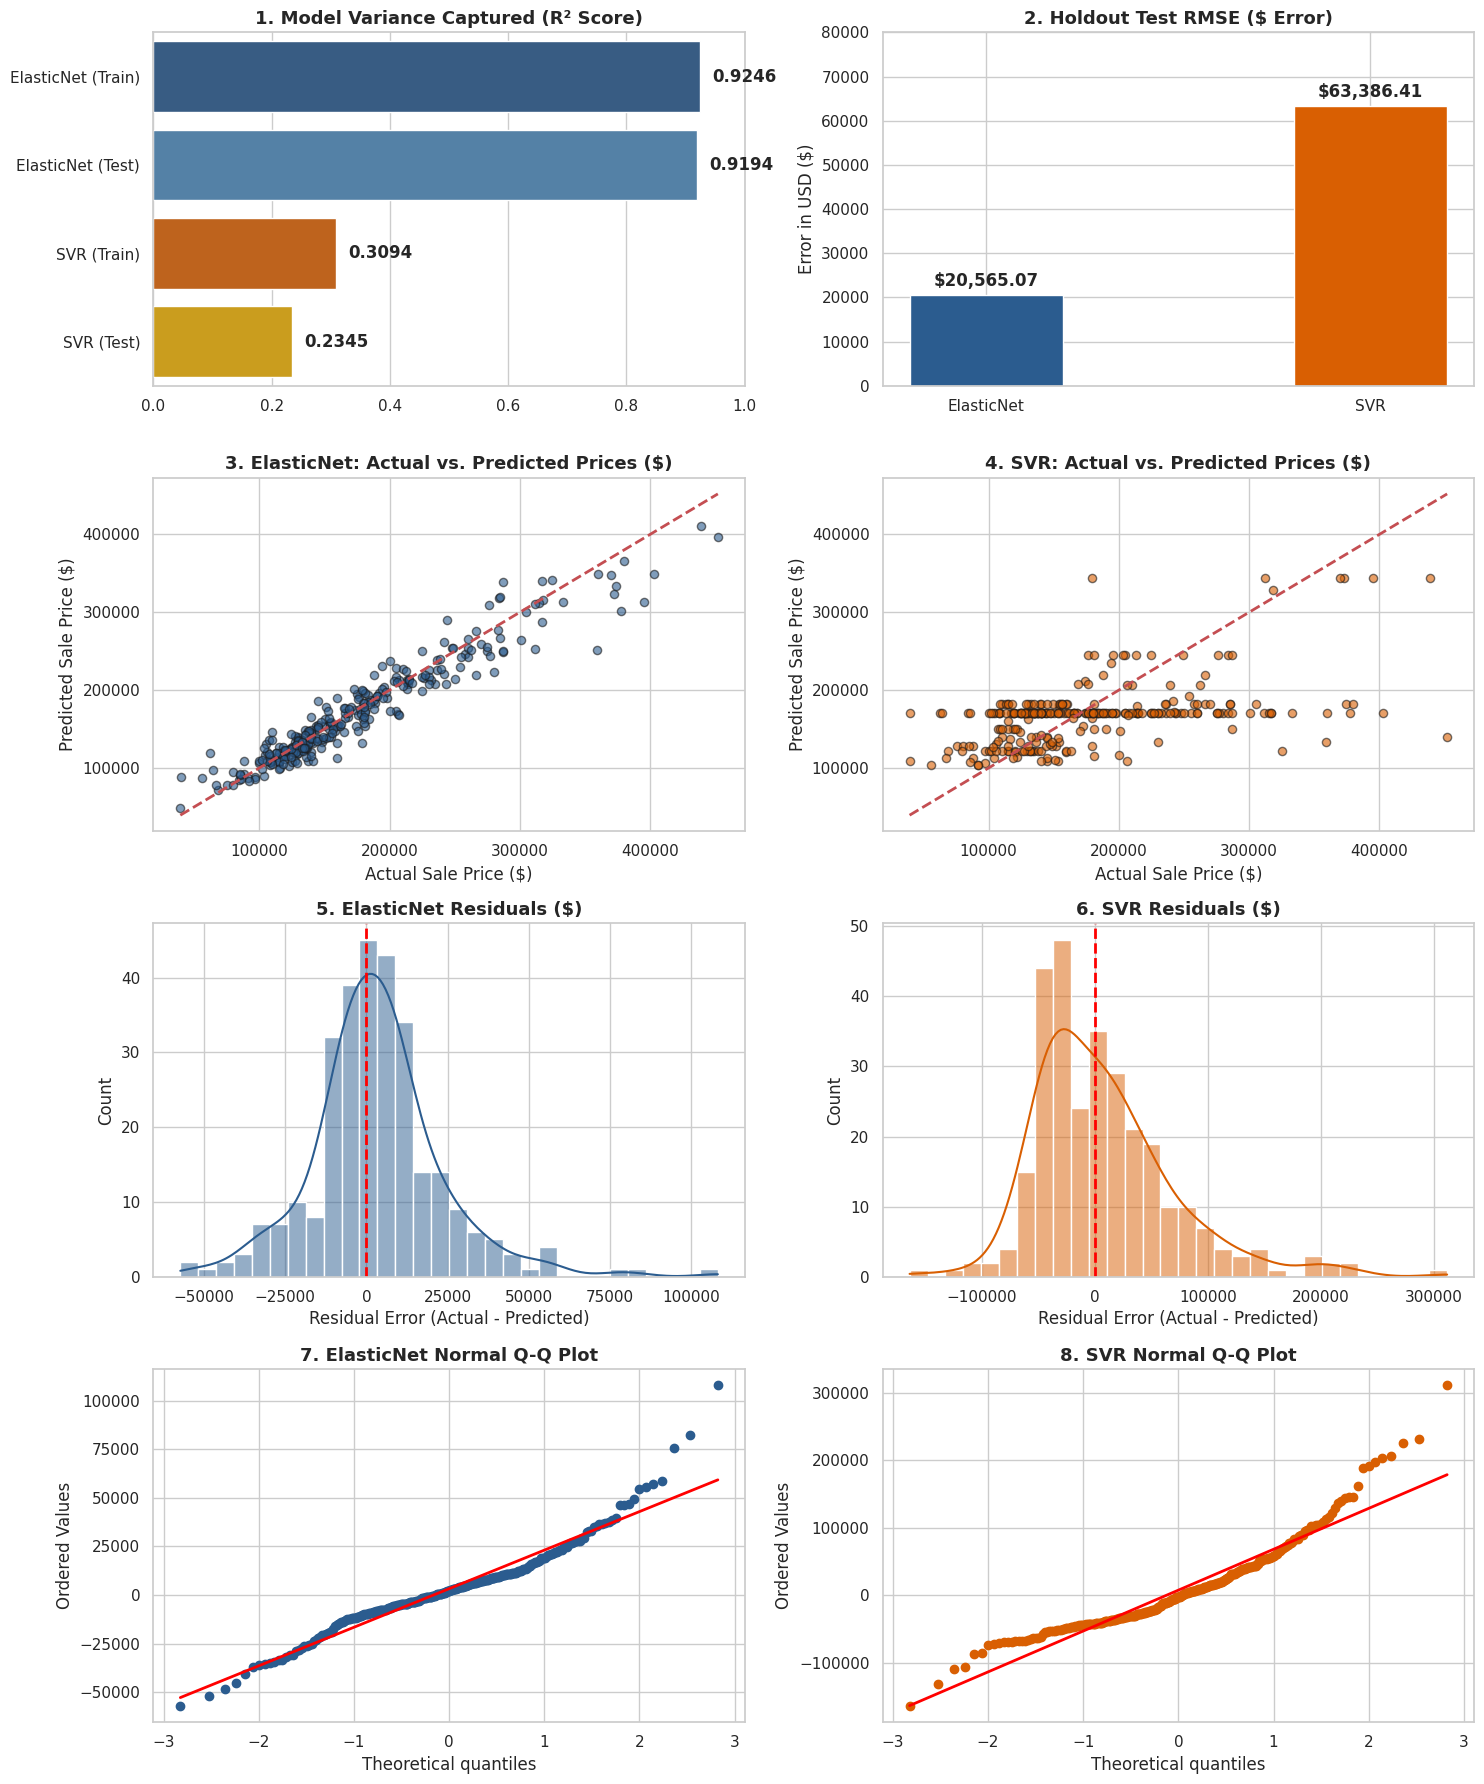

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Set visual style and expand layout to 4 rows x 2 columns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(15, 18))

# -------------------------------------------------------------------------
# Plot 1: Model R² Score Comparison
# -------------------------------------------------------------------------
models = [
    "ElasticNet (Train)",
    "ElasticNet (Test)",
    "SVR (Train)",
    "SVR (Test)",
]
r2_scores = [0.9246, 0.9194, 0.3094, 0.2345]
colors = ["#2b5c8f", "#4682b4", "#d95f02", "#e6ab02"]

sns.barplot(x=r2_scores, y=models, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title(
    "1. Model Variance Captured (R² Score)", fontsize=13, fontweight="bold"
)
axes[0, 0].set_xlim(0, 1.0)
for i, v in enumerate(r2_scores):
    axes[0, 0].text(v + 0.02, i, f"{v:.4f}", va="center", fontweight="bold")

# -------------------------------------------------------------------------
# Plot 2: Holdout Test RMSE ($ Error)
# -------------------------------------------------------------------------
test_rmse = [20565.07, 63386.41]
rmse_labels = ["ElasticNet", "SVR"]

bars = axes[0, 1].bar(
    rmse_labels, test_rmse, color=["#2b5c8f", "#d95f02"], width=0.4
)
axes[0, 1].set_title(
    "2. Holdout Test RMSE ($ Error)", fontsize=13, fontweight="bold"
)
axes[0, 1].set_ylabel("Error in USD ($)")
axes[0, 1].set_ylim(0, 80000)
for bar in bars:
    yval = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2000,
        f"${yval:,.2f}",
        ha="center",
        fontweight="bold",
    )

# -------------------------------------------------------------------------
# Plot 3: ElasticNet - Actual vs. Predicted
# -------------------------------------------------------------------------
axes[1, 0].scatter(
    y_test_dollars,
    elastic_test_pred_dollars,
    alpha=0.6,
    color="#2b5c8f",
    edgecolors="k",
    s=35,
)
axes[1, 0].plot(
    [y_test_dollars.min(), y_test_dollars.max()],
    [y_test_dollars.min(), y_test_dollars.max()],
    "r--",
    lw=2,
)
axes[1, 0].set_title(
    "3. ElasticNet: Actual vs. Predicted Prices ($)",
    fontsize=13,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Actual Sale Price ($)")
axes[1, 0].set_ylabel("Predicted Sale Price ($)")

# -------------------------------------------------------------------------
# Plot 4: SVR - Actual vs. Predicted
# -------------------------------------------------------------------------
axes[1, 1].scatter(
    y_test_dollars,
    svr_test_pred_dollars,
    alpha=0.6,
    color="#d95f02",
    edgecolors="k",
    s=35,
)
axes[1, 1].plot(
    [y_test_dollars.min(), y_test_dollars.max()],
    [y_test_dollars.min(), y_test_dollars.max()],
    "r--",
    lw=2,
)
axes[1, 1].set_title(
    "4. SVR: Actual vs. Predicted Prices ($)", fontsize=13, fontweight="bold"
)
axes[1, 1].set_xlabel("Actual Sale Price ($)")
axes[1, 1].set_ylabel("Predicted Sale Price ($)")

# -------------------------------------------------------------------------
# Plot 5: ElasticNet - Residual Distribution
# -------------------------------------------------------------------------
elastic_residuals = y_test_dollars - elastic_test_pred_dollars
sns.histplot(elastic_residuals, kde=True, ax=axes[2, 0], color="#2b5c8f", bins=30)
axes[2, 0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[2, 0].set_title(
    "5. ElasticNet Residuals ($)", fontsize=13, fontweight="bold"
)
axes[2, 0].set_xlabel("Residual Error (Actual - Predicted)")

# -------------------------------------------------------------------------
# Plot 6: SVR - Residual Distribution
# -------------------------------------------------------------------------
svr_residuals = y_test_dollars - svr_test_pred_dollars
sns.histplot(svr_residuals, kde=True, ax=axes[2, 1], color="#d95f02", bins=30)
axes[2, 1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[2, 1].set_title("6. SVR Residuals ($)", fontsize=13, fontweight="bold")
axes[2, 1].set_xlabel("Residual Error (Actual - Predicted)")

# -------------------------------------------------------------------------
# Plot 7: ElasticNet - Q-Q Plot
# -------------------------------------------------------------------------
stats.probplot(elastic_residuals, dist="norm", plot=axes[3, 0])
axes[3, 0].set_title(
    "7. ElasticNet Normal Q-Q Plot", fontsize=13, fontweight="bold"
)
axes[3, 0].get_lines()[0].set_color("#2b5c8f")  # Data points
axes[3, 0].get_lines()[1].set_color("red")  # Theoretical line
axes[3, 0].get_lines()[1].set_linewidth(2)

# -------------------------------------------------------------------------
# Plot 8: SVR - Q-Q Plot
# -------------------------------------------------------------------------
stats.probplot(svr_residuals, dist="norm", plot=axes[3, 1])
axes[3, 1].set_title("8. SVR Normal Q-Q Plot", fontsize=13, fontweight="bold")
axes[3, 1].get_lines()[0].set_color("#d95f02")  # Data points
axes[3, 1].get_lines()[1].set_color("red")  # Theoretical line
axes[3, 1].get_lines()[1].set_linewidth(2)

plt.tight_layout()
plt.show()

In [46]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

# 1. Streamlined Parameter Grid for Fast Optimization
param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8]
}

# 2. RandomizedSearchCV (Fewer iterations = Much faster)
grid_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=15,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# 3. Fit Model
print("Tuning XGBoost...")
grid_xgb.fit(X_train_ready, y_train_ready)

# 4. Print Results
print("\n================ RESULTS ================")
print(f"Best XGBoost CV RMSE: {-grid_xgb.best_score_:.5f}")
print(f"Best XGBoost Params: {grid_xgb.best_params_}\n")

# 5. Evaluate Best Estimator on Holdout Test Set
best_xgb = grid_xgb.best_estimator_
xgb_test_preds = best_xgb.predict(X_test_ready)

# Inverse transform predictions back to raw dollar values
xgb_test_dollars = pt_target.inverse_transform(xgb_test_preds.reshape(-1, 1)).flatten()

print("=== HOLDOUT TEST RMSE (DOLLARS) ===")
print(f"XGBoost Test RMSE: ${root_mean_squared_error(y_test, xgb_test_dollars):,.2f}")

Tuning XGBoost...

================ RESULTS ================
Best XGBoost CV RMSE: 0.05615
Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

=== HOLDOUT TEST RMSE (DOLLARS) ===
XGBoost Test RMSE: $20,985.77


/tmp/ipykernel_7059/1414919156.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


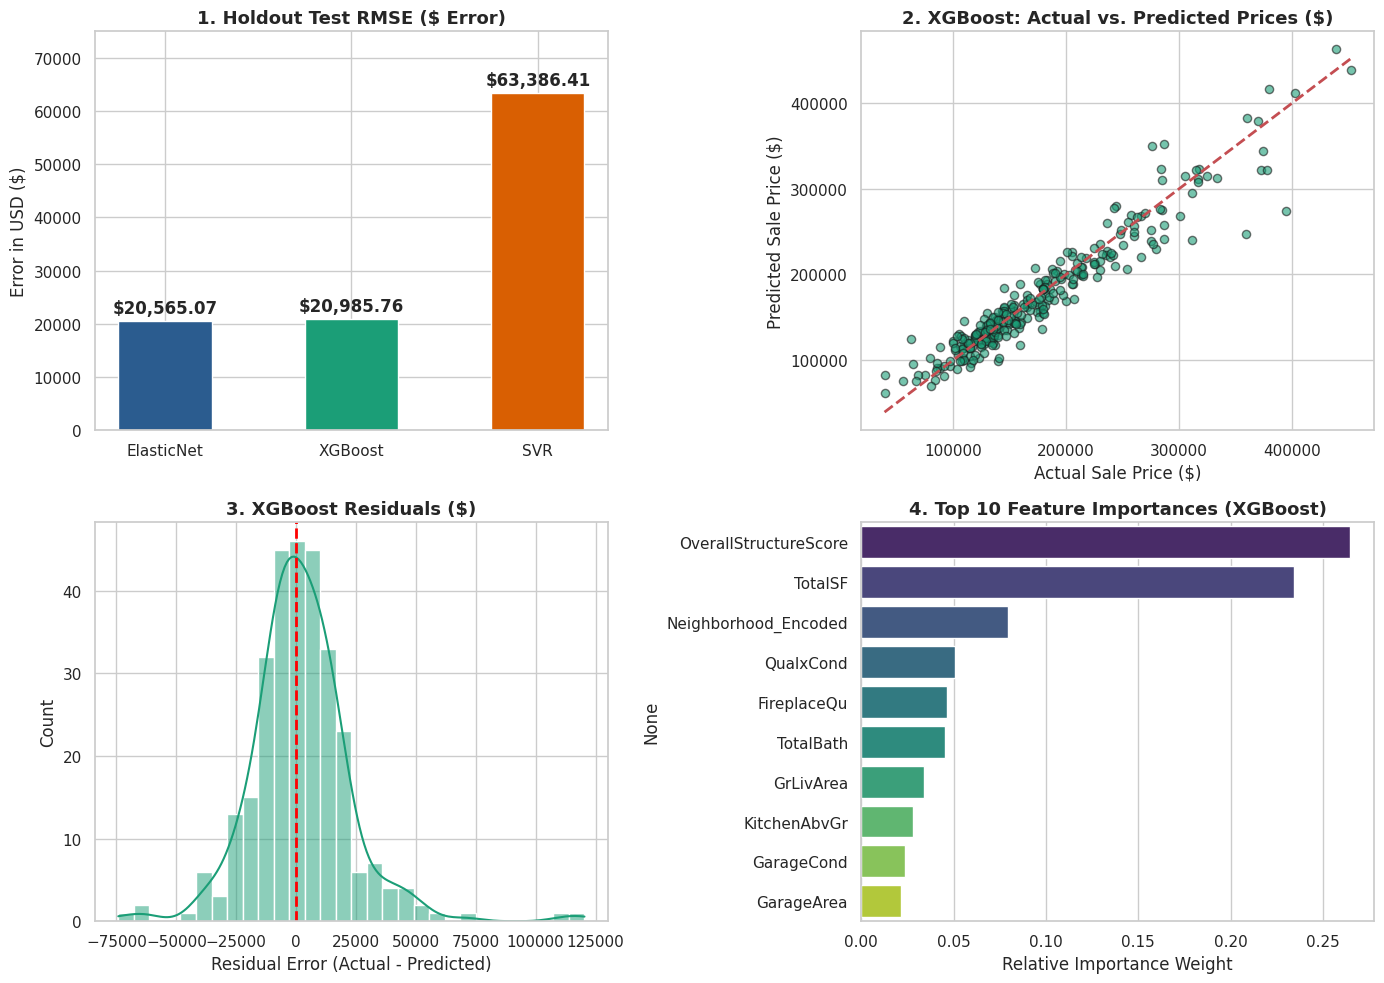

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------------------------------------------------------
# Plot 1: Test RMSE Comparison ($)
# -------------------------------------------------------------------------
models = ["ElasticNet", "XGBoost", "SVR"]
test_rmse = [20565.07, 20985.76, 63386.41]
colors = ["#2b5c8f", "#1b9e77", "#d95f02"]

bars = axes[0, 0].bar(models, test_rmse, color=colors, width=0.5)
axes[0, 0].set_title(
    "1. Holdout Test RMSE ($ Error)", fontsize=13, fontweight="bold"
)
axes[0, 0].set_ylabel("Error in USD ($)")
axes[0, 0].set_ylim(0, 75000)

for bar in bars:
  yval = bar.get_height()
  axes[0, 0].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 1500,
      f"${yval:,.2f}",
      ha="center",
      fontweight="bold",
  )

# -------------------------------------------------------------------------
# Plot 2: XGBoost - Actual vs. Predicted Prices ($)
# -------------------------------------------------------------------------
axes[0, 1].scatter(
    y_test_dollars,
    xgb_test_dollars,
    alpha=0.6,
    color="#1b9e77",
    edgecolors="k",
    s=35,
)
axes[0, 1].plot(
    [y_test_dollars.min(), y_test_dollars.max()],
    [y_test_dollars.min(), y_test_dollars.max()],
    "r--",
    lw=2,
)
axes[0, 1].set_title(
    "2. XGBoost: Actual vs. Predicted Prices ($)",
    fontsize=13,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Actual Sale Price ($)")
axes[0, 1].set_ylabel("Predicted Sale Price ($)")

# -------------------------------------------------------------------------
# Plot 3: XGBoost - Residual Error Distribution
# -------------------------------------------------------------------------
xgb_residuals = y_test_dollars - xgb_test_dollars
sns.histplot(xgb_residuals, kde=True, ax=axes[1, 0], color="#1b9e77", bins=30)
axes[1, 0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1, 0].set_title(
    "3. XGBoost Residuals ($)", fontsize=13, fontweight="bold"
)
axes[1, 0].set_xlabel("Residual Error (Actual - Predicted)")

# -------------------------------------------------------------------------
# Plot 4: Top 10 Feature Importances (XGBoost)
# -------------------------------------------------------------------------
if hasattr(X_train_ready, "columns"):
  feature_names = X_train_ready.columns
else:
  feature_names = [f"Feature {i}" for i in range(X_train_ready.shape[1])]

importances = pd.Series(
    best_xgb.feature_importances_, index=feature_names
).sort_values(ascending=False)[:10]

sns.barplot(
    x=importances.values, y=importances.index, ax=axes[1, 1], palette="viridis"
)
axes[1, 1].set_title(
    "4. Top 10 Feature Importances (XGBoost)", fontsize=13, fontweight="bold"
)
axes[1, 1].set_xlabel("Relative Importance Weight")

plt.tight_layout()
plt.show()

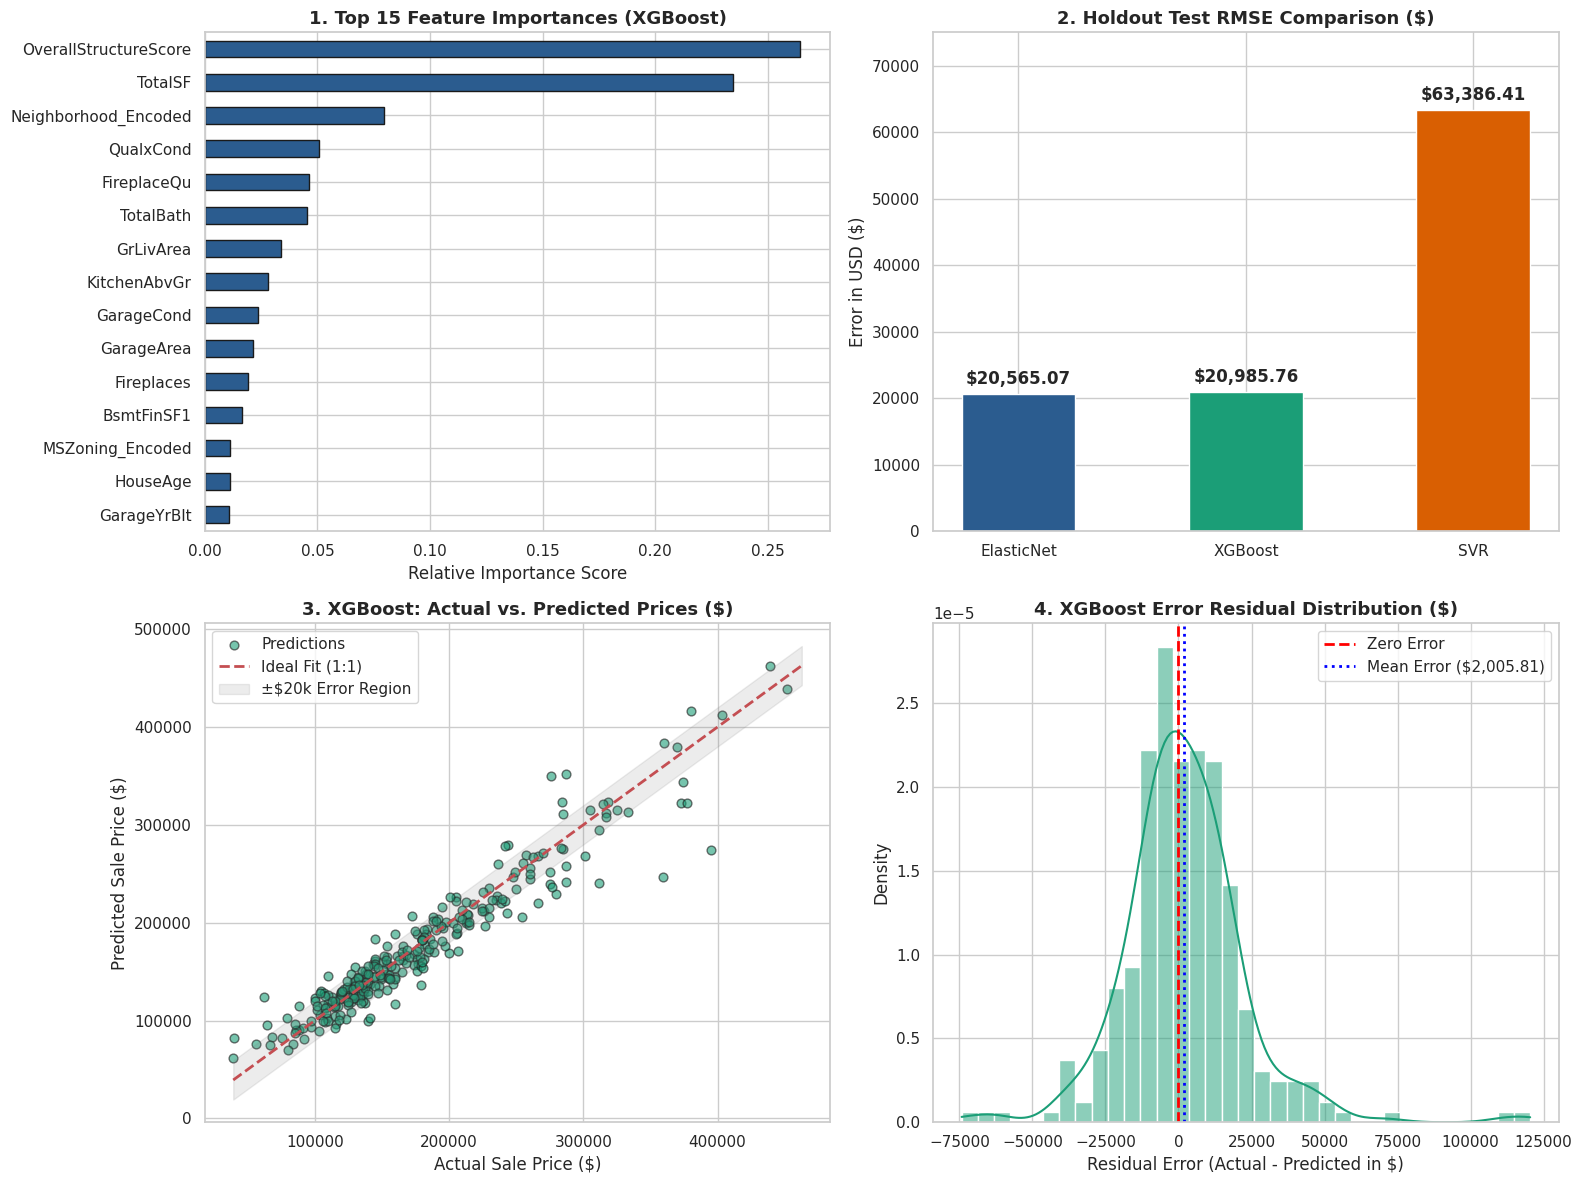

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -------------------------------------------------------------------------
# 1. Top 15 Feature Importances (XGBoost)
# -------------------------------------------------------------------------
if hasattr(X_train_ready, "columns"):
  feature_names = X_train_ready.columns
else:
  feature_names = [f"Feature {i}" for i in range(X_train_ready.shape[1])]

importances = pd.Series(
    best_xgb.feature_importances_, index=feature_names
).sort_values(ascending=True)[-15:]  # Top 15 for a generous view

importances.plot(kind="barh", ax=axes[0, 0], color="#2b5c8f", edgecolor="k")
axes[0, 0].set_title(
    "1. Top 15 Feature Importances (XGBoost)", fontsize=13, fontweight="bold"
)
axes[0, 0].set_xlabel("Relative Importance Score")

# -------------------------------------------------------------------------
# 2. Comprehensive Model Test RMSE Comparison
# -------------------------------------------------------------------------
models = ["ElasticNet", "XGBoost", "SVR"]
test_rmses = [20565.07, 20985.76, 63386.41]
bar_colors = ["#2b5c8f", "#1b9e77", "#d95f02"]

bars = axes[0, 1].bar(models, test_rmses, color=bar_colors, width=0.5)
axes[0, 1].set_title(
    "2. Holdout Test RMSE Comparison ($)", fontsize=13, fontweight="bold"
)
axes[0, 1].set_ylabel("Error in USD ($)")
axes[0, 1].set_ylim(0, 75000)

for bar in bars:
  yval = bar.get_height()
  axes[0, 1].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 1500,
      f"${yval:,.2f}",
      ha="center",
      fontweight="bold",
  )

# -------------------------------------------------------------------------
# 3. XGBoost Actual vs. Predicted Prices with Error Band
# -------------------------------------------------------------------------
axes[1, 0].scatter(
    y_test_dollars,
    xgb_test_dollars,
    alpha=0.6,
    color="#1b9e77",
    edgecolors="k",
    s=40,
    label="Predictions",
)
min_val = min(y_test_dollars.min(), xgb_test_dollars.min())
max_val = max(y_test_dollars.max(), xgb_test_dollars.max())
axes[1, 0].plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Ideal Fit (1:1)"
)

# Optional: Add +/- 20k error bounds for visual context
axes[1, 0].fill_between(
    [min_val, max_val],
    [min_val - 20000, max_val - 20000],
    [min_val + 20000, max_val + 20000],
    color="gray",
    alpha=0.15,
    label="±$20k Error Region",
)

axes[1, 0].set_title(
    "3. XGBoost: Actual vs. Predicted Prices ($)",
    fontsize=13,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Actual Sale Price ($)")
axes[1, 0].set_ylabel("Predicted Sale Price ($)")
axes[1, 0].legend(loc="upper left")

# -------------------------------------------------------------------------
# 4. Detailed Residual Distribution with KDE & Quartiles
# -------------------------------------------------------------------------
xgb_residuals = y_test_dollars - xgb_test_dollars
sns.histplot(
    xgb_residuals,
    kde=True,
    ax=axes[1, 1],
    color="#1b9e77",
    bins=35,
    stat="density",
)
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axes[1, 1].axvline(
    np.mean(xgb_residuals),
    color="blue",
    linestyle=":",
    linewidth=2,
    label=f"Mean Error (${np.mean(xgb_residuals):,.2f})",
)

axes[1, 1].set_title(
    "4. XGBoost Error Residual Distribution ($)", fontsize=13, fontweight="bold"
)
axes[1, 1].set_xlabel("Residual Error (Actual - Predicted in $)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

--- Model Evaluation ---
RMSE: 25,754.12
MAE:  18,080.58
R²:   0.8736
------------------------



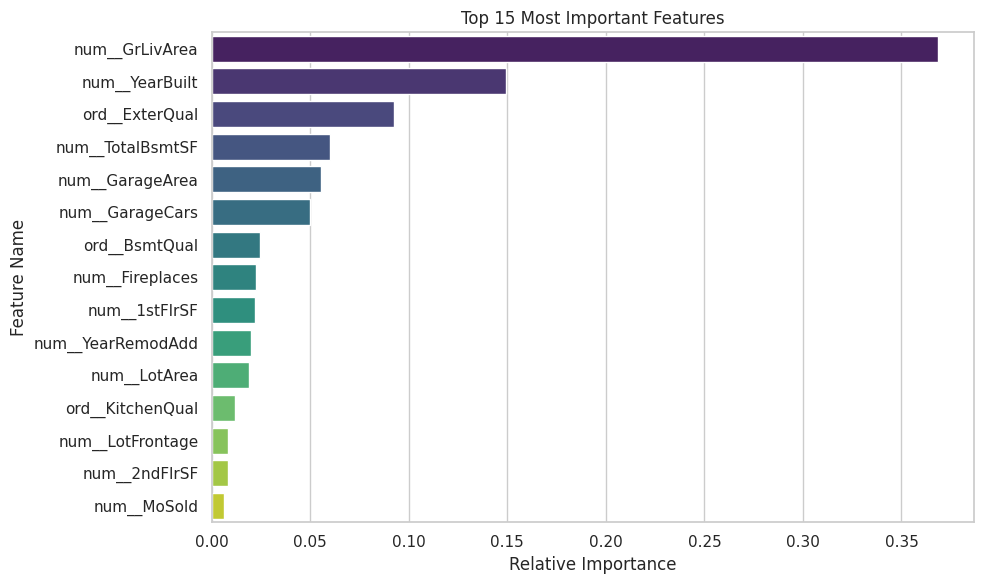

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1. Data Prep & Train-Test Split
# ---------------------------------------------------------
# Drop 'Id' and 'SalePrice' from the feature matrix[cite: 1]
X = df.drop(columns=['Id', 'SalePrice'])

# Log-transform the target variable[cite: 1]
y = np.log1p(df['SalePrice'])

# Perform an 80/20 train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 2. Preprocessing ColumnTransformer
# ---------------------------------------------------------
# Numerical pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal pipeline
ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Nominal pipeline
nom_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all transformations 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('ord', ord_transformer, ordinal_features),
        ('nom', nom_transformer, nominal_features)
    ],
    remainder='drop' # Drops any columns not explicitly defined in your lists
)

# ---------------------------------------------------------
# 3. Machine Learning Pipeline & Fitting
# ---------------------------------------------------------
# Combine preprocessor with RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Fit the pipeline on the training data
model_pipeline.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Evaluation
# ---------------------------------------------------------
# Predict on the test set
y_pred_log = model_pipeline.predict(X_test)

# Transform predictions and actual values back to original scale
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("--- Model Evaluation ---")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")
print("------------------------\n")

# ---------------------------------------------------------
# 5. Extract and Plot Top 15 Feature Importances
# ---------------------------------------------------------
# Extract feature names from the ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# Extract feature importances from the RandomForest
importances = model_pipeline.named_steps['regressor'].feature_importances_

# Create a DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top 15 features
top_15_features = importance_df.head(15)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Most Important Features')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()